In [1]:
from itertools import product
import pickle
from tqdm import tqdm, trange

import numpy as np
from numpy.linalg import eigh
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from corner import corner as corner_plot

from scipy import special, stats
from scipy.stats import gaussian_kde, chi2
from scipy.interpolate import RegularGridInterpolator

import os

from local_utils import delaunaytor
from generate_events import MixtureModel

plt.style.use("tableau-colorblind10")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 25
plt.rcParams["text.usetex"] = True

In [2]:
# file_3d=np.load('data_test_3dim_3D_1000_events_10000_samples_1000000_injections/data.npz')
# observed_events=file_3d['observed_events']
# mins, maxs = observed_events.min(axis=0), observed_events.max(axis=0)
# pad = (maxs - mins) * 0.1
# bounds = list(zip(mins - pad, maxs + pad))
# corners_3d = np.array(list(product(*bounds)))

# prior=2

# def get_filenames(runs, ndim):
#     if prior==2:
#         return [f"runs/run_test_data_{ndim}dim_prior_rate_2_{run}" for run in runs]
#     else:
#         return [f"runs/run_test_data_{ndim}dim_{run}" for run in runs]
        

# def get_covariance(ndim):
#     if ndim == 2:
#         return np.array([[8, 2], [2, 3]])
#     elif ndim == 3:
#         return np.array([[8, 2, 1], [2, 3, 0.5], [1, 0.5, 2]])
#     elif ndim == 4:
#         return np.array(
#             [[8, 2, 1, 0], [2, 3, 0.5, 0], [1, 0.5, 2, 0.1], [0, 0, 0.1, 1.5]]
#         )
#     else:
#         raise NotImplemented
        
# def get_corners(ndim): 


#     return {
#             2: np.array([
#                 [-7.44119683, -5.01374023],
#                 [-7.44119683,  5.35412894],
#                 [ 8.29080419, -5.01374023],
#                 [ 8.29080419,  5.35412894],
#             ]),
#             3: corners_3d,
#             4: np.array([
#                 [-10.10824238,  -5.82820447,  -6.13421008,  -5.14605239],
#                 [-10.10824238,  -5.82820447,  -6.13421008,   4.26606076],
#                 [-10.10824238,  -5.82820447,   6.31054764,  -5.14605239],
#                 [-10.10824238,  -5.82820447,   6.31054764,   4.26606076],
#                 [-10.10824238,   6.63628867,  -6.13421008,  -5.14605239],
#                 [-10.10824238,   6.63628867,  -6.13421008,   4.26606076],
#                 [-10.10824238,   6.63628867,   6.31054764,  -5.14605239],
#                 [-10.10824238,   6.63628867,   6.31054764,   4.26606076],
#                 [  8.74414845,  -5.82820447,  -6.13421008,  -5.14605239],
#                 [  8.74414845,  -5.82820447,  -6.13421008,   4.26606076],
#                 [  8.74414845,  -5.82820447,   6.31054764,  -5.14605239],
#                 [  8.74414845,  -5.82820447,   6.31054764,   4.26606076],
#                 [  8.74414845,   6.63628867,  -6.13421008,  -5.14605239],
#                 [  8.74414845,   6.63628867,  -6.13421008,   4.26606076],
#                 [  8.74414845,   6.63628867,   6.31054764,  -5.14605239],
#                 [  8.74414845,   6.63628867,   6.31054764,   4.26606076],
#             ]),
#     }[ndim]

observed_events = np.loadtxt('samples.txt')
corners_3d = np.array([[-10,-10,-10,],[10,-10,-10],
                        [-10,10,-10],[10,10,-10],
                        [-10,-10,10],[10,-10,10],
                        [-10,10,10],[10,10,10]])

print(corners_3d)

min_prior=-10
max_prior=20
    
# def sample_triangulation_prior(ndim, num_samples):
#     corners = get_corners(ndim)
#     mins = corners.min(axis=0)
#     maxs = corners.max(axis=0)

#     n_leaves = np.random.randint(8, 100, size=num_samples)
    
#     return [
#         np.c_[
#             np.vstack([corners, np.random.uniform(mins, maxs, size=(N, ndim))]),
#             np.random.uniform(min_prior, max_prior, size=N+corners.shape[0])
#         ]
#         for N in n_leaves
#     ]

[[-10 -10 -10]
 [ 10 -10 -10]
 [-10  10 -10]
 [ 10  10 -10]
 [-10 -10  10]
 [ 10 -10  10]
 [-10  10  10]
 [ 10  10  10]]


In [3]:
# def get_covariance(ndim):
#     if ndim == 2:
#         return np.array([[8, 2], [2, 3]])
#     elif ndim == 3:
#         return np.array([[8, 2, 1], [2, 3, 0.5], [1, 0.5, 2]])
#     elif ndim == 4:
#         return np.array(
#             [[8, 2, 1, 0], [2, 3, 0.5, 0], [1, 0.5, 2, 0.1], [0, 0, 0.1, 1.5]]
#         )
#     else:  # Random positive-definite matrix
#         A = np.random.randn(ndim, ndim)
#         cov = np.dot(A, A.T) + np.eye(ndim)
#         return cov

In [4]:
def triangulation_sizes(backend_file, nsteps, nwalkers):
        
    with open(backend_file, "rb") as f:
        back = pickle.load(f)
    return np.array([
        back.inds["tri"][step, 0, walker].sum()
        for step, walker in product(range(nsteps), range(nwalkers))
    ])

In [5]:
# runs = [1]
nwalkers = 4
nsteps = 10_000
nburn = 20_000

In [6]:
backend_file = 'backend_events1000_samples10000'

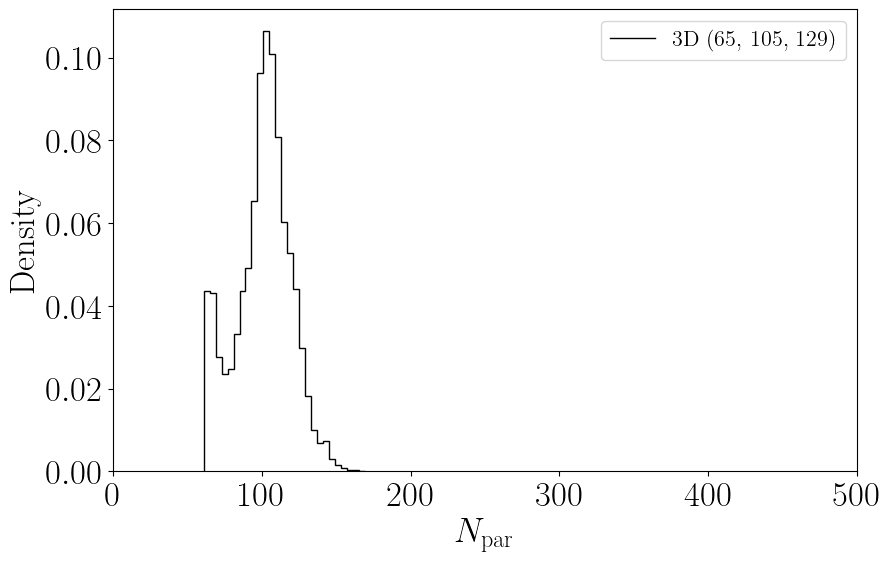

In [7]:
fig, ax = plt.subplots(figsize=(1.2 * 8, 1.2 * 5))
ax.set(
    yscale="linear",
    xlabel=r"$N_{\mathrm{par}}$",
    ylabel="Density",
    xlim=(0, 500),
)

ls = ["-", "--", ":"]

ind=0
ndim=3
tri_sizes = triangulation_sizes(backend_file, nsteps, nwalkers)

tri_sizes = np.stack(tri_sizes).ravel() * (ndim + 1) + 2**ndim + 1 

unique, counts = np.unique(tri_sizes, return_counts=True)
fractions = counts / tri_sizes.size

l, m, h = np.quantile(tri_sizes, [0.05, 0.5, 0.95]).astype(int)

edges = np.concatenate(([unique[0]], unique))
ax.stairs(
    fractions,
    edges, 
    color='black', 
    ls=ls[ind], 
    label=f"{ndim}D ({l}, {m}, {h})"
)

ax.legend()
plt.show()
plt.close()

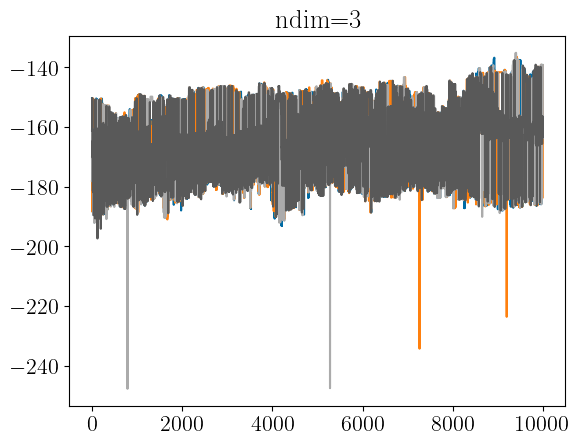

In [8]:
with open(backend_file, "rb") as f:
    back = pickle.load(f)
fig, ax = plt.subplots()
ax.set_rasterized(True)
ax.set(title=f"{ndim=}")
for w in range(nwalkers):
    ax.plot(back.get_log_like()[:, 0, w])
plt.show()
plt.close()

In [9]:
all_triangulations = []

with open(backend_file, "rb") as f:
    back = pickle.load(f)
    triangulations = [
        back.chain["tri"][step, 0, walker][back.inds["tri"][step, 0, walker]]
        for step, walker in product(range(nsteps), range(nwalkers))
    ]

    corner_weights = np.array(
        [
            back.chain["corners"][step, 0, walker]
            for step, walker in product(range(nsteps), range(nwalkers))
        ]
    )

for ind in tqdm(range(len(triangulations))):
    all_triangulations.extend([
        np.vstack([triangulations[ind], np.c_[corners_3d, corner_weights[ind].T]])                
    ])

100%|████████████████████████████████| 40000/40000 [00:00<00:00, 177554.90it/s]


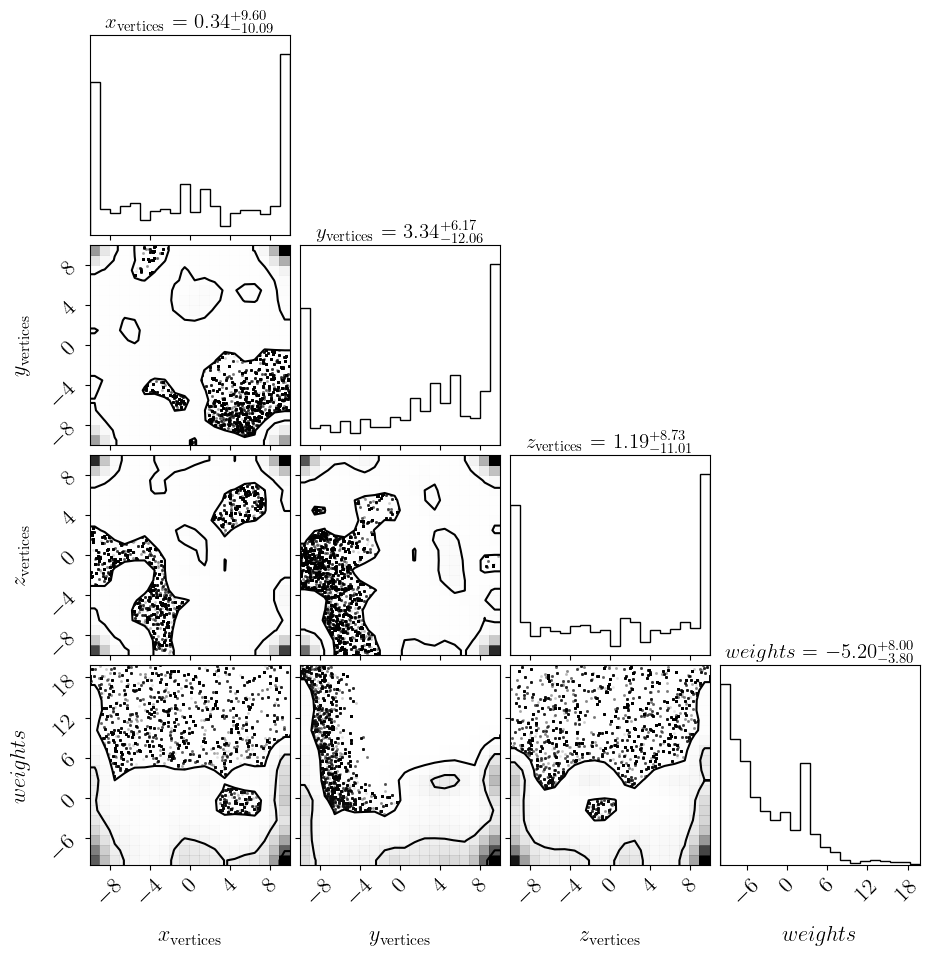

In [10]:
ws = np.hstack([tri[:, -1] for tri in all_triangulations])
vertices = np.vstack([tri[:, :-1] for tri in all_triangulations])    
corner_plot(np.c_[vertices, ws], smooth=True, levels=[0.05, 0.5, 0.95],
            labels=[r"$x_\mathrm{vertices}$", r"$y_\mathrm{vertices}$", r"$z_\mathrm{vertices}$", r"$weights$"],
            show_titles=True,
            title_kwargs={"fontsize": 15},
           )

plt.show()
plt.close()

In [11]:
def q_flat(x):
    ans=1/(5-(-15))

    return ans


def kl_divergence_kde_p_known_q(p_samples, q_pdf, base=np.e, bandwidth='scott'):
    """
    Estimate KL divergence D_KL(P || Q) where:
      - P is only known via samples (estimated with KDE)
      - Q is known analytically via q_pdf(x)
    
    Parameters:
        p_samples (array): 1D array of samples from P
        q_pdf (function): function that returns q(x) given x
        base (float): logarithm base (e.g., np.e or 2)
        bandwidth: bandwidth for KDE (default: 'scott')
    
    Returns:
        float: Estimated KL divergence D_KL(P || Q)
    """
    p_samples = np.asarray(p_samples)
    kde = gaussian_kde(p_samples, bw_method=bandwidth)

    # Evaluate both p(x) and q(x) at the sample points
    p_kde_vals = kde(p_samples)
    q_vals = q_pdf(p_samples)

    # Avoid division by zero or log(0)
    epsilon = 1e-12
    p_kde_vals = np.clip(p_kde_vals, epsilon, None)
    q_vals = np.clip(q_vals, epsilon, None)

    log_ratio = np.log(p_kde_vals / q_vals)
    kl = np.mean(log_ratio)

    return kl / np.log(base)


def kl_divergence_kde(p_samples, q_samples, base=np.e, bandwidth='scott'):
    from scipy.stats import gaussian_kde
    """
    Estimate delta divergence D_delta(P || Q) where:
      - P is only known via samples (estimated with KDE)
      - Q is known analytically via q_pdf(x)
    
    Parameters:
        p_samples (array): 1D array of samples from P
        q_pdf (function): function that returns q(x) given x
        base (float): logarithm base (e.g., np.e or 2)
        bandwidth: bandwidth for KDE (default: 'scott')
    
    Returns:
        float: Estimated delta divergence D_delta(P || Q)
    """
    p_samples = np.asarray(p_samples)
    kde_p = gaussian_kde(p_samples, bw_method=bandwidth)

    q_samples = np.asarray(q_samples)
    kde_q = gaussian_kde(q_samples, bw_method=bandwidth)

    # Evaluate both p(x) and q(x) at the sample points
    p_kde_vals = kde_p(p_samples)
    q_kde_vals = kde_q(p_samples)

    # Avoid division by zero or log(0)
    epsilon = 1e-12
    p_kde_vals = np.clip(p_kde_vals, epsilon, None)
    q_kde_vals = np.clip(q_kde_vals, epsilon, None)

    log_ratio = np.log(p_kde_vals / q_kde_vals)
    delta = np.mean(log_ratio)

    return delta / np.log(base)

In [12]:
# class ResampleDelaunaytor(delaunaytor.CPUDelaunayInterpolator):
    
#     def re_sample(self, proposals, nmax=5000):
#             volumes = self.volumes()

#             prop_simplices, prop_b = self.simplex_and_barycenters(
#                 proposals
#             )

#             cartesian_coordinates = (
#                     prop_b[..., None]
#                     * self.triangulation.points[self.triangulation.simplices][prop_simplices]
#                 ).sum(axis=1)


#             log_probs=self._interpolate(prop_simplices, prop_b)
            
#             log_to_accept = log_probs - log_probs.max()
    
#             accepted = np.log(np.random.random(size=len(proposals))) < log_to_accept
#             accepted_points = proposals[accepted]

#             return accepted_points[:nmax]

In [13]:
def conditional_gaussian(mu, Sigma, z0):
    """
    Conditional distribution of (X,Y) given Z=z0
    where (X,Y,Z) ~ N(mu, Sigma).
    """
    # Partition mean and covariance
    mu_xy = mu[:2]
    mu_z = mu[2]

    Sigma_xx = Sigma[:2, :2]
    Sigma_xz = Sigma[:2, 2:]
    Sigma_zx = Sigma[2:, :2]
    Sigma_zz = Sigma[2:, 2:]

    z0 = np.atleast_1d(z0)      # make it a 1D array
    mu_z = np.atleast_1d(mu_z)

    # Conditional mean and covariance
    mu_cond = mu_xy + Sigma_xz @ np.linalg.inv(Sigma_zz) @ (z0 - mu_z)
    Sigma_cond = Sigma_xx - Sigma_xz @ np.linalg.inv(Sigma_zz) @ Sigma_zx

    return mu_cond, Sigma_cond


def plot_ellipse(mu, cov, ax, n_std=1, **kwargs):
    """
    Plot the ellipse corresponding to an n_std 'sigma' contour
    of a 2D Gaussian with mean mu and covariance cov.
    """
    from numpy.linalg import eigh
    
    # Eigen-decomposition
    vals, vecs = eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    
    # Chi2 threshold for 2 dof
    chi2_val = chi2.ppf({1:0.68, 2:0.95, 3:0.997}[n_std], df=2)
    
    # Width and height of ellipse
    width, height = 2 * np.sqrt(vals * chi2_val)
    
    # Orientation
    angle = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    
    from matplotlib.patches import Ellipse
    ellipse = Ellipse(xy=mu, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

In [14]:
# min_x, min_y, min_z = get_corners(3).min(axis=0)
# max_x, max_y, max_z = get_corners(3).max(axis=0)

min_x, min_y, min_z = -10, -10, -10
max_x, max_y, max_z = 10, 10, 10

x_grid = np.linspace(min_x, max_x, 51)
y_grid = np.linspace(min_y, max_y, 50)
z_grid = np.linspace(min_z, max_z, 49)

X, Y, Z = np.meshgrid(x_grid, y_grid, z_grid)
grid = np.c_[X.ravel(), Y.ravel(), Z.ravel()]

dx = x_grid[1] - x_grid[0]
dy = y_grid[1] - y_grid[0]
dz = z_grid[1] - z_grid[0]

# print(log_rate.shape)

print(x_grid)
print(y_grid)
print(z_grid)
print(grid)

[-10.   -9.6  -9.2  -8.8  -8.4  -8.   -7.6  -7.2  -6.8  -6.4  -6.   -5.6
  -5.2  -4.8  -4.4  -4.   -3.6  -3.2  -2.8  -2.4  -2.   -1.6  -1.2  -0.8
  -0.4   0.    0.4   0.8   1.2   1.6   2.    2.4   2.8   3.2   3.6   4.
   4.4   4.8   5.2   5.6   6.    6.4   6.8   7.2   7.6   8.    8.4   8.8
   9.2   9.6  10. ]
[-10.          -9.59183673  -9.18367347  -8.7755102   -8.36734694
  -7.95918367  -7.55102041  -7.14285714  -6.73469388  -6.32653061
  -5.91836735  -5.51020408  -5.10204082  -4.69387755  -4.28571429
  -3.87755102  -3.46938776  -3.06122449  -2.65306122  -2.24489796
  -1.83673469  -1.42857143  -1.02040816  -0.6122449   -0.20408163
   0.20408163   0.6122449    1.02040816   1.42857143   1.83673469
   2.24489796   2.65306122   3.06122449   3.46938776   3.87755102
   4.28571429   4.69387755   5.10204082   5.51020408   5.91836735
   6.32653061   6.73469388   7.14285714   7.55102041   7.95918367
   8.36734694   8.7755102    9.18367347   9.59183673  10.        ]
[-10.          -9.58333333  

In [16]:
# triangulations = all_triangulations[3]
# print(len(triangulations))

selected_tris = range(0, len(all_triangulations), 20)
num_triangulations = len(selected_tris)

log_rate = np.zeros((num_triangulations, grid.shape[0]))
the_num_events = np.zeros(num_triangulations)

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate[ind] = this_delo.interpolate(grid)
    
square_rate = log_rate.reshape(num_triangulations, y_grid.shape[0], x_grid.shape[0], z_grid.shape[0])

100%|██████████████████████████████████████| 2000/2000 [00:50<00:00, 39.41it/s]


In [19]:
median = np.quantile(square_rate, 0.5, axis=0)
low = np.quantile(square_rate, 0.05, axis=0)
high = np.quantile(square_rate, 0.95, axis=0)

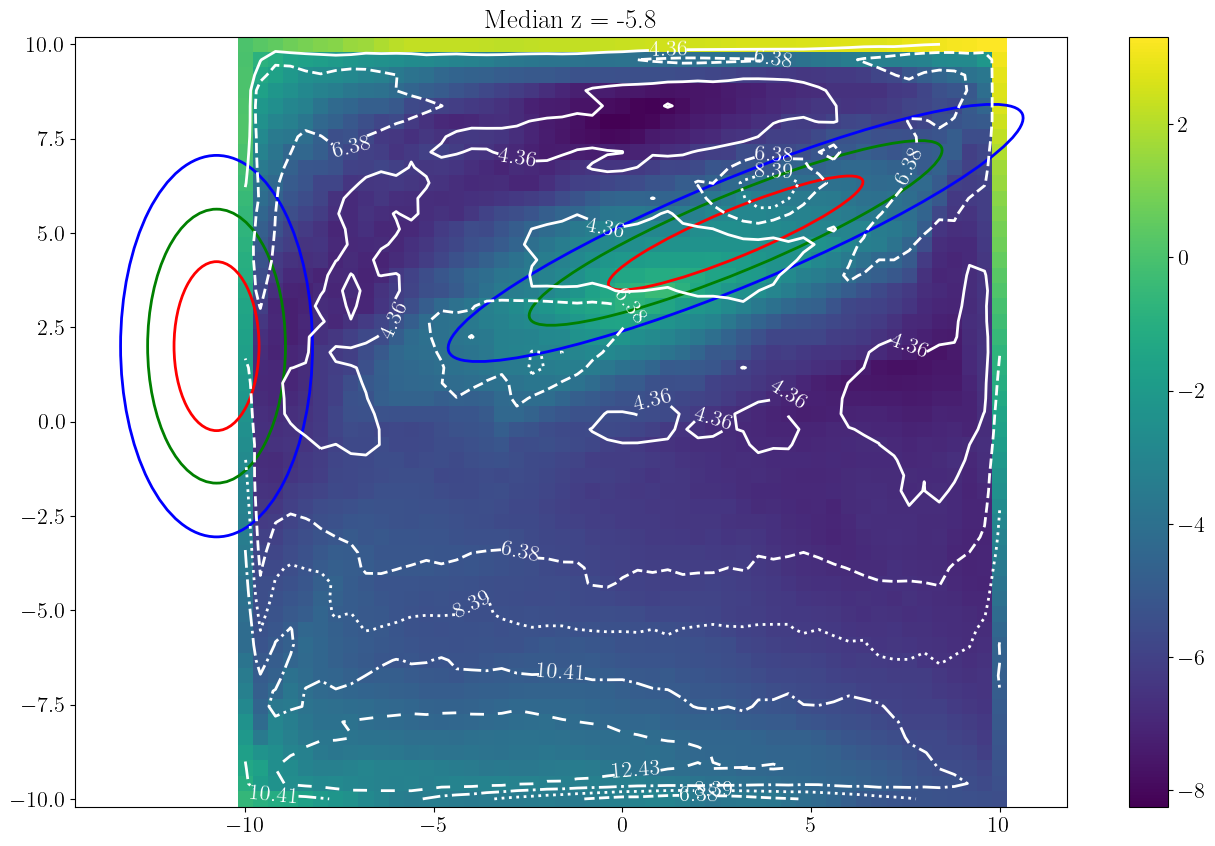

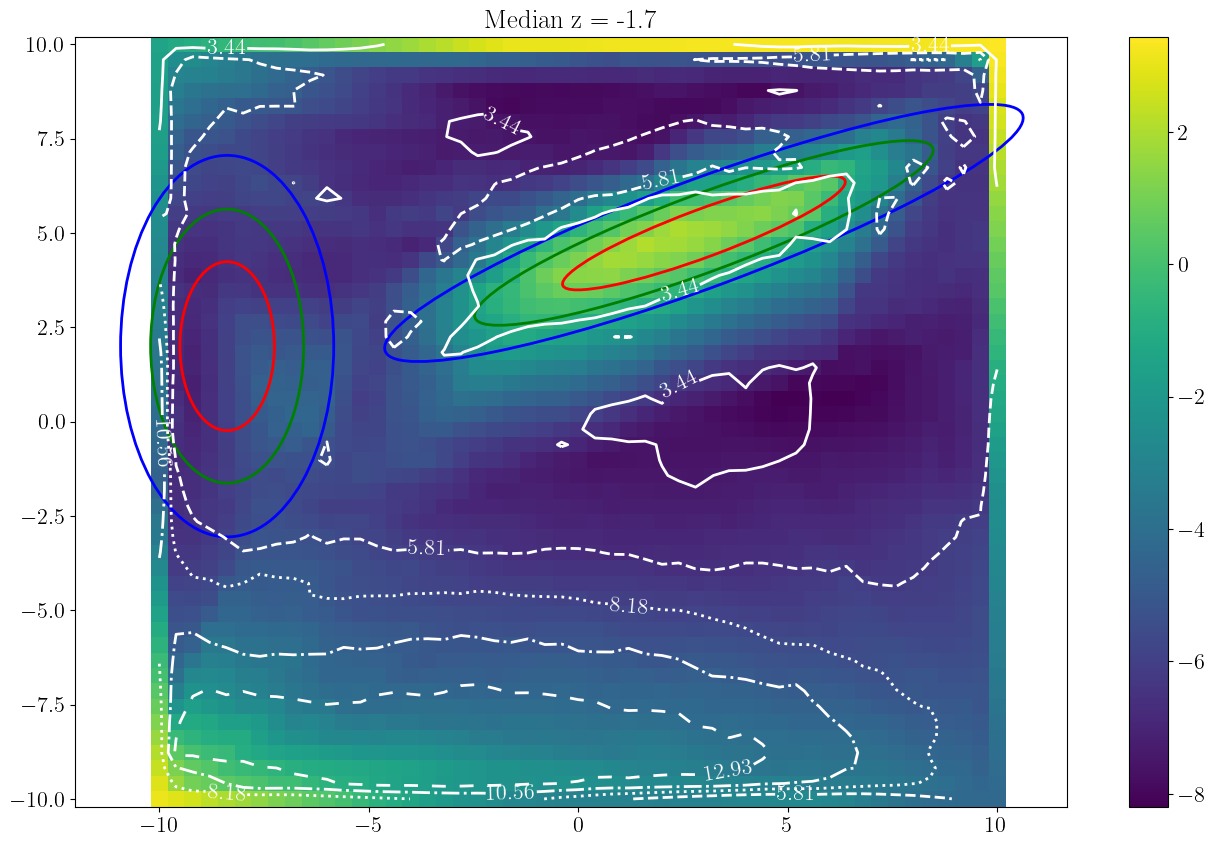

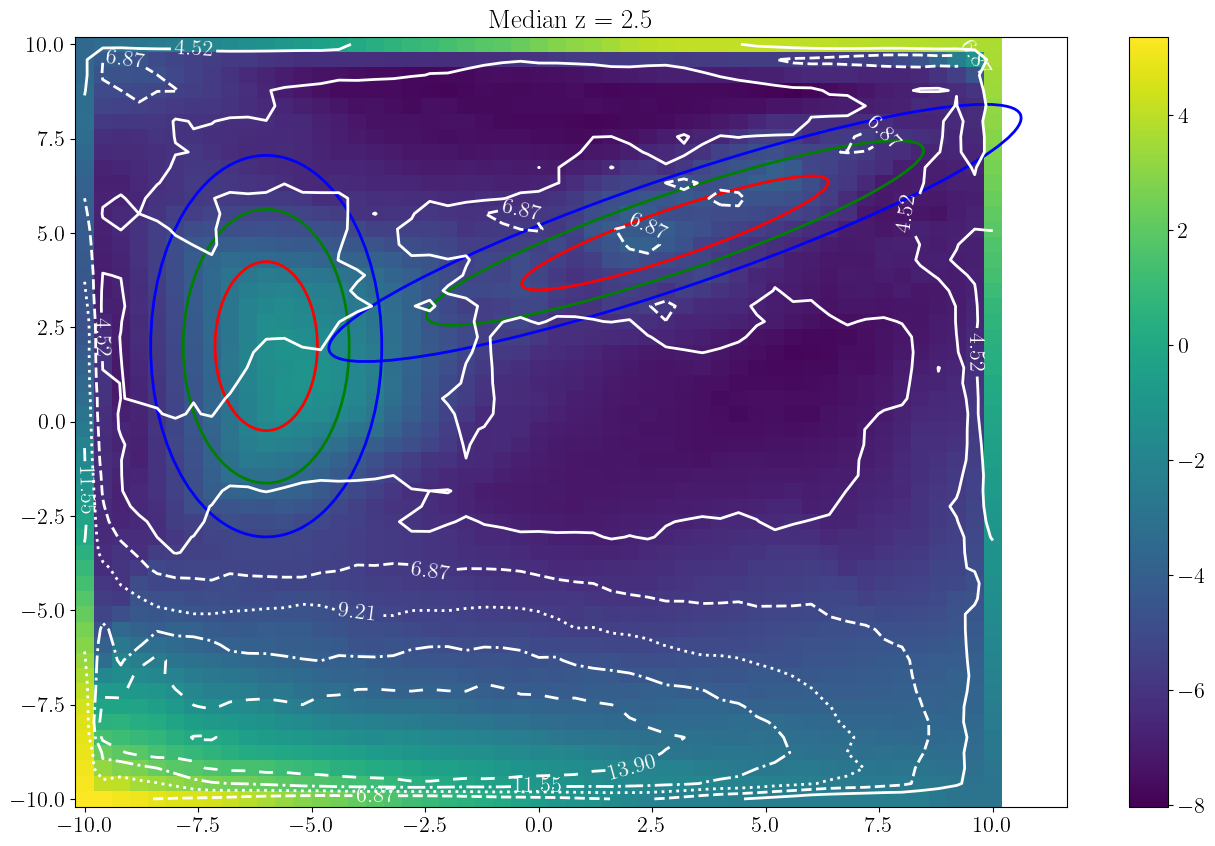

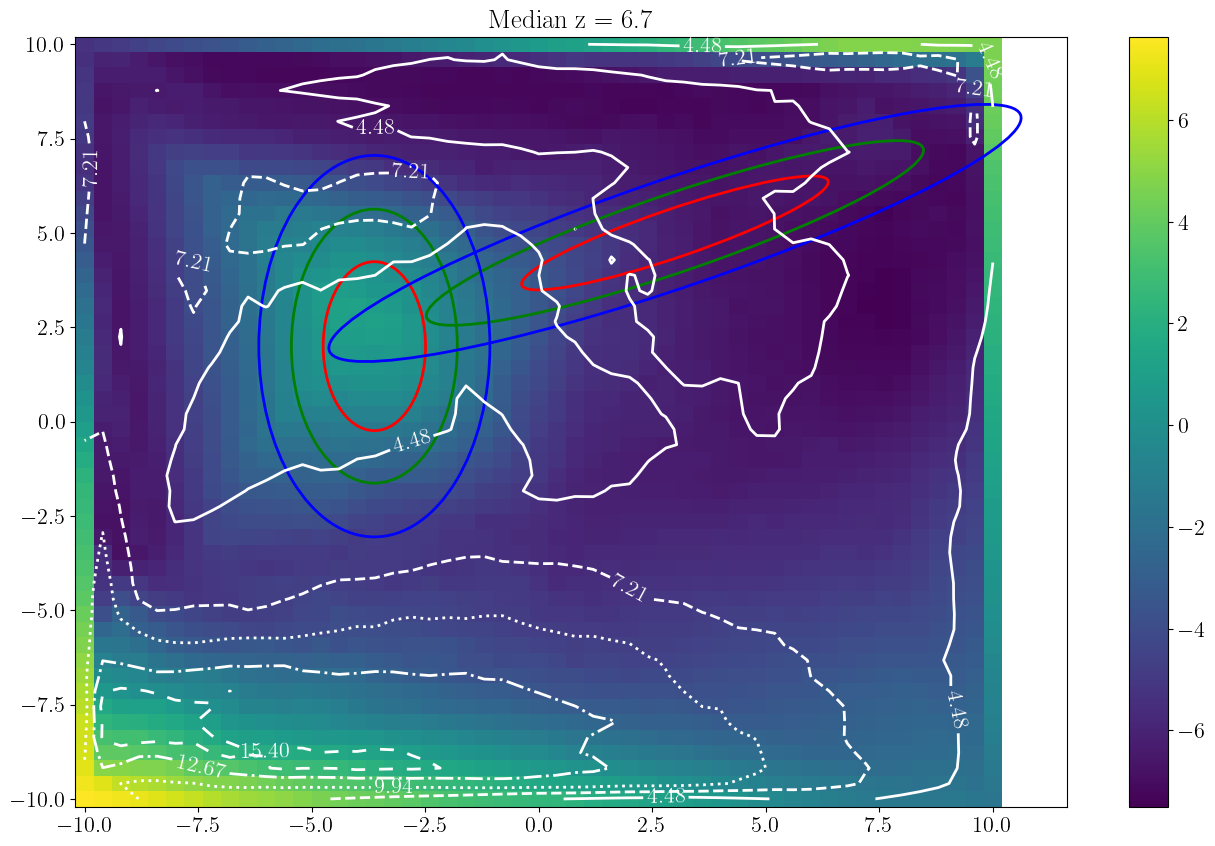

In [20]:
z_indices = [10, 20, 30, 40]

# cov=get_covariance(3)
# mean=np.array([5.,5.,5.])
cov1 = np.array([[5,2,0],[2,1,0],[0,0,1.5]])
mean1 = np.array([3,5,-2])
cov2 = np.array([[1.7,0,2],[0,2.2,0],[2,0,3.5]])
mean2 = np.array([-4.,2,6])

# print(mean)

# print(cov.shape,mean.shape)

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize

for z_idx in z_indices:
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set(title=f"Median z = {z_grid[z_idx]:.1f}")
    c = ax.pcolormesh(x_grid, y_grid, median[:, :, z_idx])    
    fig.colorbar(c)

    
    # Calculate the difference
    diff = high[:, :, z_idx] - low[:, :, z_idx]

    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours = ax.contour(
        x_grid, y_grid, diff, 
        levels=levels, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )


    mu_cond1, Sigma_cond1 = conditional_gaussian(mean1, cov1, z_grid[z_idx])
    mu_cond2, Sigma_cond2 = conditional_gaussian(mean2, cov2, z_grid[z_idx])

    colors = ['r','g','b']

    for n, c in zip([1,2,3], colors):
        plot_ellipse(mu_cond1, Sigma_cond1, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=f"{n}σ")
        plot_ellipse(mu_cond2, Sigma_cond2, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=f"{n}σ")


    # Optional: add labels to contours
    ax.clabel(contours, fmt="%.2f")
    
    plt.show()
    plt.close()

In [21]:

x_grid_coarse= np.linspace(min_x, max_x, 19)
y_grid_coarse = np.linspace(min_y, max_y, 20)
z_grid_coarse = np.linspace(min_z, max_z, 21)

X_coarse, Y_coarse, Z_coarse = np.meshgrid(x_grid_coarse, y_grid_coarse, z_grid_coarse)
grid_coarse = np.c_[X_coarse.ravel(), Y_coarse.ravel(), Z_coarse.ravel()]

dx_coarse = x_grid_coarse[1] - x_grid_coarse[0]
dy_coarse = y_grid_coarse[1] - y_grid_coarse[0]
dz_coarse = z_grid_coarse[1] - z_grid_coarse[0]

In [22]:
log_rate_coarse = np.zeros((num_triangulations, grid_coarse.shape[0]))
the_num_events = np.zeros(num_triangulations)

for ind, tri_ind in enumerate(tqdm(selected_tris)):
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(all_triangulations[tri_ind])
    log_rate_coarse[ind] = this_delo.interpolate(grid_coarse)
    
square_rate_coarse = log_rate_coarse.reshape(num_triangulations, y_grid_coarse.shape[0], x_grid_coarse.shape[0], z_grid_coarse.shape[0])

100%|█████████████████████████████████████| 2000/2000 [00:04<00:00, 404.80it/s]


In [23]:
nsamples_prior=1000
log_rate_prior_coarse = np.zeros((nsamples_prior, grid_coarse.shape[0]))

for i in tqdm(range(nsamples_prior)):

    nleaves_i=np.random.randint(8,100)

    tri_i=np.zeros((nleaves_i+8,4))

    tri_i[:nleaves_i,0]=np.random.uniform(min_x,max_x,nleaves_i)
    tri_i[:nleaves_i,1]=np.random.uniform(min_y,max_y,nleaves_i)
    tri_i[:nleaves_i,2]=np.random.uniform(min_z,max_z,nleaves_i)
    tri_i[:,3]=np.random.uniform(-10,20,nleaves_i+8)

    tri_i[-8,0]=min_x
    tri_i[-8,1]=min_y
    tri_i[-8,2]=min_z

    tri_i[-7,0]=min_x
    tri_i[-7,1]=min_y
    tri_i[-7,2]=max_z


    tri_i[-6,0]=min_x
    tri_i[-6,1]=max_y
    tri_i[-6,2]=min_z


    tri_i[-5,0]=min_x
    tri_i[-5,1]=max_y
    tri_i[-5,2]=max_z


    tri_i[-4,0]=max_x
    tri_i[-4,1]=min_y
    tri_i[-4,2]=min_z

    tri_i[-3,0]=max_x
    tri_i[-3,1]=min_y
    tri_i[-3,2]=max_z

    tri_i[-2,0]=max_x
    tri_i[-2,1]=max_y
    tri_i[-2,2]=min_z

    tri_i[-1,0]=max_x
    tri_i[-1,1]=max_y
    tri_i[-1,2]=max_z

   
    this_delo = delaunaytor.CPUDelaunayInterpolator()
    this_delo.triangulate(tri_i)
    log_rate_prior_coarse[i] = this_delo.interpolate(grid_coarse)
    

100%|█████████████████████████████████████| 1000/1000 [00:02<00:00, 335.79it/s]


In [24]:
square_rate_prior_coarse = log_rate_prior_coarse.reshape(nsamples_prior, y_grid_coarse.shape[0], x_grid_coarse.shape[0], z_grid_coarse.shape[0])

In [25]:
kl_divs=np.zeros((len(y_grid_coarse),len(x_grid_coarse),len(z_grid_coarse)))

for i in tqdm(range(len(y_grid_coarse))):
    for j in tqdm(range(len(x_grid_coarse))):
        for k in range(len(z_grid_coarse)):

        # print(i,j)

            # if (i==0 and j==0 and k==0) or (i==0 and j==99 and k==0) or (i==99 and j==0 and k==0) or (i==99 and j==99 and k==0) or (i==0 and j==0 and k==99) or (i==0 and j==99 and k==99) or (i==99 and j==0 and k==99) or (i==99 and j==99 and k==1):
            if (i==0 and j==0 and k==0) or (i==0 and j==19 and k==0) or (i==19 and j==0 and k==0) or (i==19 and j==19 and k==0) or (i==0 and j==0 and k==19) or (i==0 and j==19 and k==99) or (i==19 and j==0 and k==19) or (i==19 and j==19 and k==1):

                kl_divs[i,j,k]=kl_divergence_kde_p_known_q(square_rate_coarse[:,i,j,k],q_flat)

            else:

                kl_divs[i,j,k]=kl_divergence_kde(square_rate_coarse[:,i,j,k],square_rate_prior_coarse[:,i,j,k])

100%|██████████████████████████████████████████| 20/20 [11:26<00:00, 34.33s/it]


In [26]:
interp_kl = RegularGridInterpolator((z_grid_coarse, x_grid_coarse, y_grid_coarse), kl_divs.T, bounds_error=False, fill_value=np.nan)

interp_delta = RegularGridInterpolator((z_grid, x_grid, y_grid), (low-high).T, bounds_error=False, fill_value=np.nan)

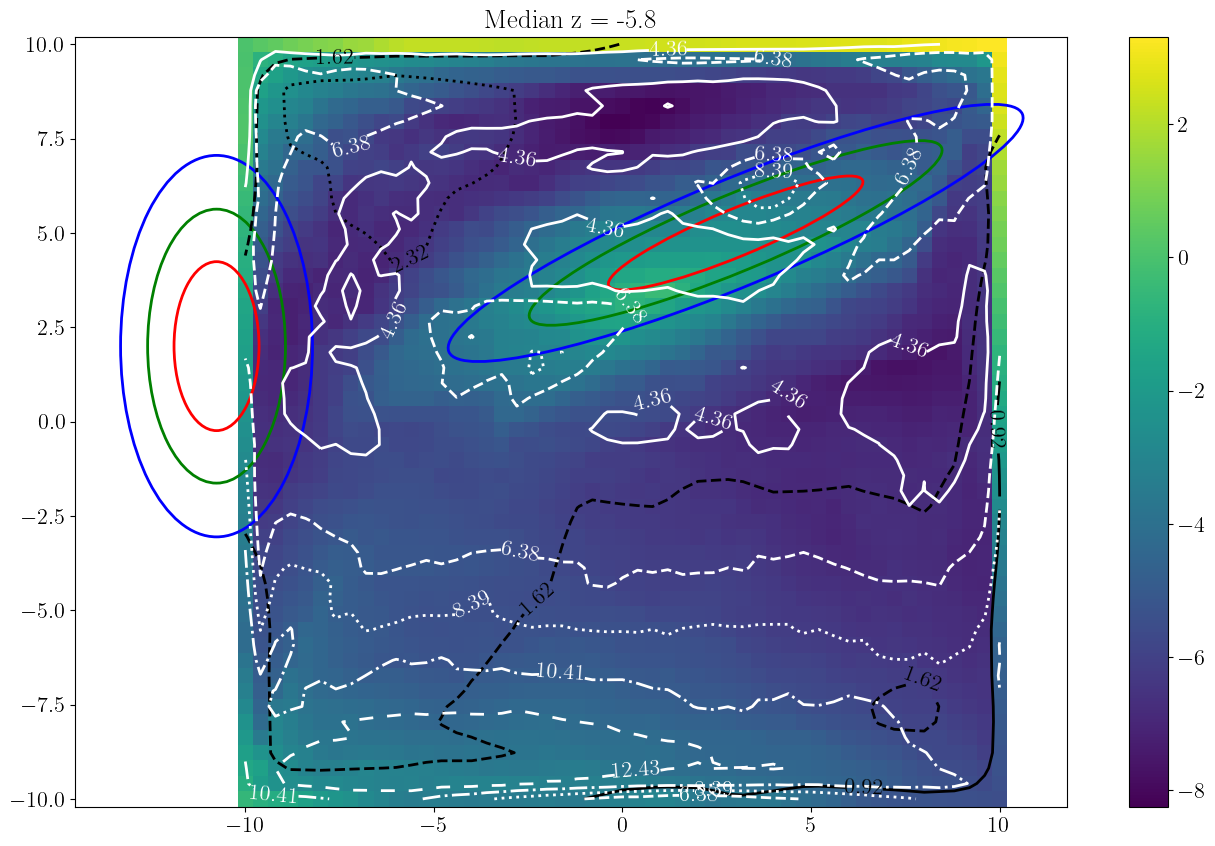

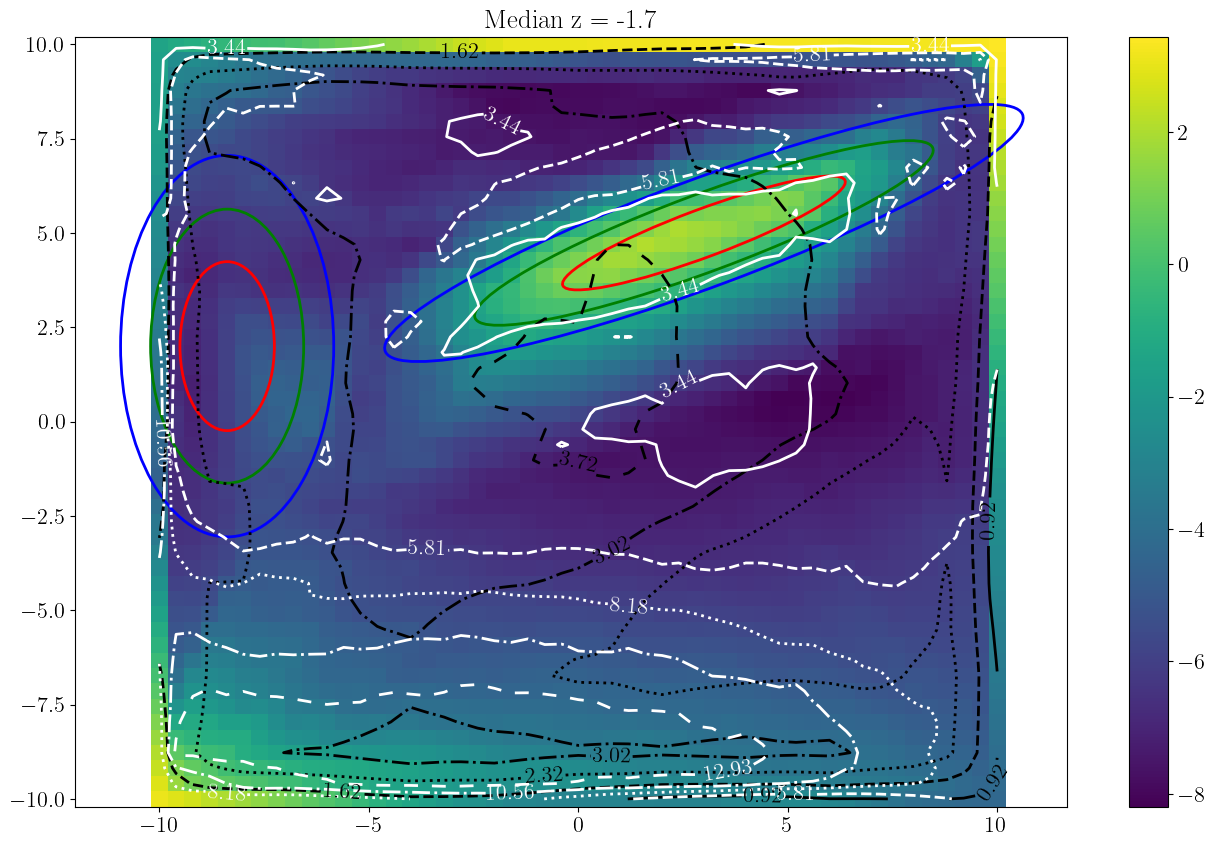

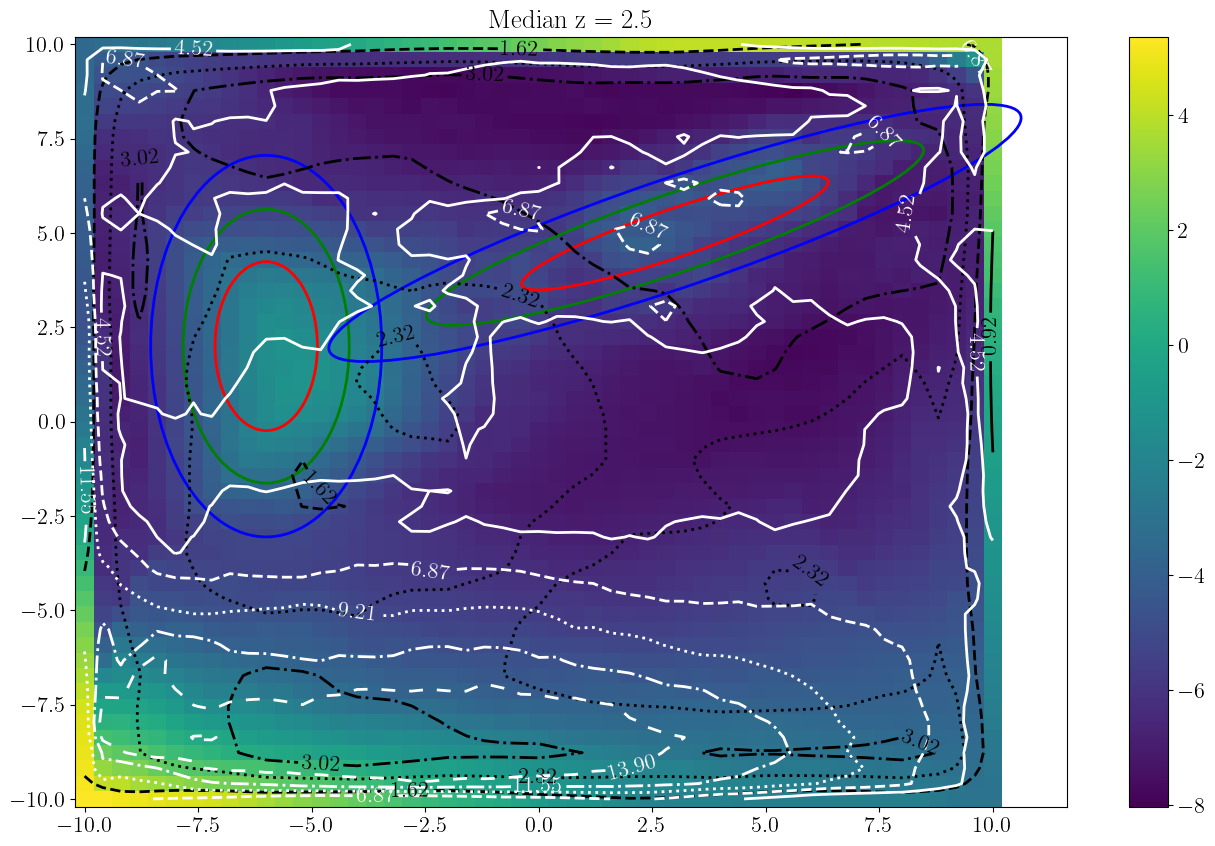

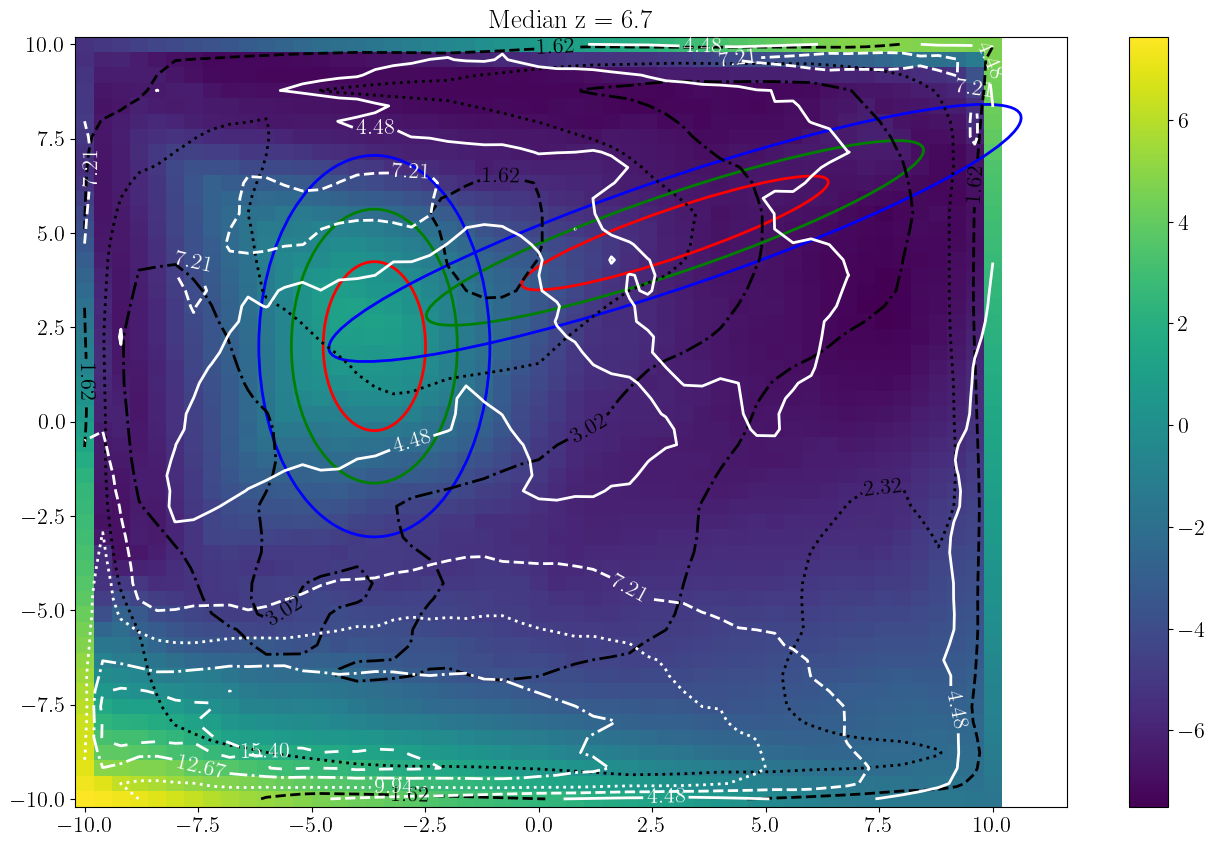

In [27]:
z_indices = [10, 20, 30, 40]

# cov=get_covariance(3)
# mean=np.array([5.,5.,5.])

# print(mean)

# print(cov.shape,mean.shape)

linestyles = ['solid', 'dashed', 'dotted', 'dashdot', (0, (5, 5))]  # You can add more or customize

for z_idx in z_indices:
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set(title=f"Median z = {z_grid[z_idx]:.1f}")
    c = ax.pcolormesh(x_grid, y_grid, median[:, :, z_idx])    
    fig.colorbar(c)


    Xz0, Yz0, Zz0 = np.meshgrid(x_grid, y_grid, np.array([z_grid[z_idx]]))
    grid_z0 = np.c_[Xz0.ravel(), Yz0.ravel(), Zz0.ravel()]

    # print(grid_z0.shape)
    # print(interp_kl(grid_z0))
    
    diff = high[:, :, z_idx] - low[:, :, z_idx]
    # Define contour levels (choose appropriate values for your data)
    n_contours = min(5, len(linestyles))
    levels_diff = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

    levels_kl = np.linspace(np.nanmin(kl_divs), np.nanmax(kl_divs), n_contours + 2)[1:-1]  # avoid min/max

    # Plot contours with different linestyles
    contours_kl = ax.contour(
        x_grid, y_grid, interp_kl(grid_z0).reshape(len(y_grid),len(x_grid)), 
        levels=levels_kl, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='black'
    )


    contours_diff = ax.contour(
        x_grid, y_grid, diff, 
        levels=levels_diff, 
        linestyles=linestyles[:n_contours],
        linewidths=2, 
        colors='white'
    )


    mu_cond1, Sigma_cond1 = conditional_gaussian(mean1, cov1, z_grid[z_idx])
    mu_cond2, Sigma_cond2 = conditional_gaussian(mean2, cov2, z_grid[z_idx])

    colors = ['r','g','b']

    for n, c in zip([1,2,3], colors):
        plot_ellipse(mu_cond1, Sigma_cond1, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=f"{n}σ")
        plot_ellipse(mu_cond2, Sigma_cond2, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=f"{n}σ")


    # Optional: add labels to contours
    ax.clabel(contours_kl, fmt="%.2f")
    ax.clabel(contours_diff, fmt="%.2f")
    
    plt.show()
    plt.close()

/tmp/ipykernel_68463/2964028527.py:17: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 1600x1000 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(sc, ax=ax0)


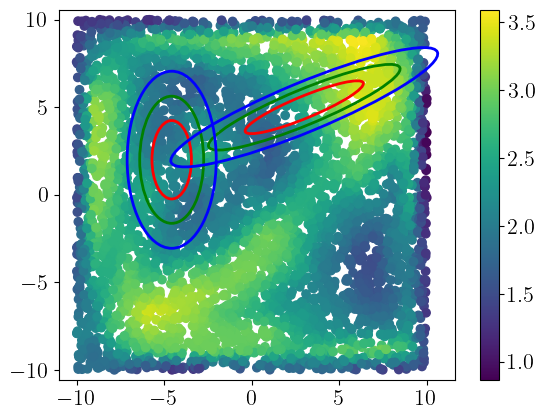

In [28]:
fig0,ax0=plt.subplots()

samples_try=np.zeros((5000,3))

# samples_try[:,0]=5
# samples_try[:,1]=np.random.uniform(min_x,max_x,5000)
# samples_try[:,2]=np.random.uniform(min_z,max_z,5000)


samples_try[:,0]=np.random.uniform(min_x,max_x,5000)
samples_try[:,1]=np.random.uniform(min_x,max_x,5000)
samples_try[:,2]=5


sc=ax0.scatter(samples_try[:,0],samples_try[:,1],c=interp_kl(samples_try))

fig.colorbar(sc, ax=ax0)

# print(np.amax(high-low),np.amin(high-low))

mu_cond1, Sigma_cond1 = conditional_gaussian(mean1, cov1, 5)
mu_cond2, Sigma_cond2 = conditional_gaussian(mean2, cov2, 5)

colors = ['r','g','b']

for n, c in zip([1,2,3], colors):
    plot_ellipse(mu_cond1, Sigma_cond1, ax0, n_std=n, edgecolor=c, fill=False, lw=2, label=f"{n}σ")
    plot_ellipse(mu_cond2, Sigma_cond2, ax0, n_std=n, edgecolor=c, fill=False, lw=2, label=f"{n}σ")
    
plt.axis('equal')
plt.show()
plt.close()

In [43]:
# kl_levels = np.linspace(0.1, 3, 20)
kl_levels = np.linspace(0, np.amax(kl_divs), 20)[1:-1]
xmin_kl={}
xmax_kl={}
ymin_kl={}
ymax_kl={}
zmin_kl={}
zmax_kl={}
for kl in kl_levels:
    ndraw=10000000
    proposals=np.zeros((ndraw,3))

    proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
    proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
    proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)


    inds_proposal_keep=np.argwhere(interp_kl(proposals)>kl-0.02)[:,0]

    xmin_kl[kl]=np.amin(proposals[inds_proposal_keep,0])
    xmax_kl[kl]=np.amax(proposals[inds_proposal_keep,0])
    ymin_kl[kl]=np.amin(proposals[inds_proposal_keep,1])
    ymax_kl[kl]=np.amax(proposals[inds_proposal_keep,1])
    zmin_kl[kl]=np.amin(proposals[inds_proposal_keep,2])
    zmax_kl[kl]=np.amax(proposals[inds_proposal_keep,2])


    

In [44]:
samples_per_tri = 1_000
num_triangulations = len(selected_tris)
ndraw=10000


ints_kl={}
# volume = np.prod(get_corners(3).max(axis=0) - get_corners(3).min(axis=0))
volume = np.prod(corners_3d.max(axis=0) - corners_3d.min(axis=0))
for kl in kl_levels:

    nprop=0
    nkeep=0
    nkeep_old=0

    print(kl)

    proposals=np.zeros((ndraw,3))

    while nkeep<ndraw:
        

        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(min_z,max_z,ndraw-nkeep)


        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_kl(new_points)>kl)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)

        nkeep+=len(inds_proposal_keep)

        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

        nkeep_old+=len(inds_proposal_keep)

    print(len(proposals))


    frac_kept = nkeep / nprop


    ints_kl[kl]=np.zeros(num_triangulations)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        # samples_ind=this_delo.condition_sample_3d(samples_per_tri, xmin_kl[kl], xmax_kl[kl], ymin_kl[kl], ymax_kl[kl], zmin_kl[kl], zmax_kl[kl], interp, kl, weight_fun=None)
        # # print(len(samples_ind))
        # if len(samples_ind)<samples_per_tri:
        #     inds_to_use=np.random.choice(np.arange(len(samples_ind)),samples_per_tri,replace=True)
        #     samples_ind=samples_ind[inds_to_use]
        
        mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        # frac_kept = len(inds_proposal_keep) / len(proposals)
        
        # print(mean_fx,frac_kept,volume)
        ints_kl[kl][ind]= mean_fx * frac_kept * volume
        # ints_kl[kl][ind]= mean_fx * volume

0.7659518105802939
10000


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:11<00:00, 174.32it/s]


1.5319036211605879
10000


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:11<00:00, 177.88it/s]


2.297855431740882
10000


...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:06<00:00, 288.47it/s]


13.021180779864997
10000


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:08<00:00, 230.03it/s]


13.78713259044529
10000


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:06<00:00, 304.57it/s]


In [45]:
true_quantities_kl = np.zeros(len(kl_levels))

ndim = 3
true_N = 1000
# gt_distro = stats.multivariate_normal(mean, cov)
gt_distro = MixtureModel(
        dist1 = stats.multivariate_normal(mean1, cov1),
        dist2 = stats.multivariate_normal(mean2, cov2),
        weight1 = 0.7,
    )

# volume = np.prod(get_corners(3).max(axis=0) - get_corners(3).min(axis=0))
volume = np.prod(corners_3d.max(axis=0) - corners_3d.min(axis=0))
for kl_ind, kl_level in enumerate(kl_levels):

    nprop=0
    nkeep=0
    nkeep_old=0

    print(kl_level)

    proposals=np.zeros((ndraw,3))

    while nkeep<ndraw:
        

        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(min_z,max_z,ndraw-nkeep)


        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_kl(new_points)>kl_level)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)

        nkeep+=len(inds_proposal_keep)

        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

        nkeep_old+=len(inds_proposal_keep)

    print(len(proposals))


    frac_kept = nkeep / nprop  
        
    # re_samples = this_delo.re_sample(proposals[inds_proposal_keep], nmax=samples_per_tri)
    
    mean_fx = gt_distro.pdf(proposals).mean()
    # frac_kept = len(inds_proposal_keep) / len(proposals)
    
    true_quantities_kl[kl_ind] = true_N * mean_fx * frac_kept * volume

0.7659518105802939
10000
1.5319036211605879
10000
2.297855431740882
10000
3.0638072423211757
10000
3.8297590529014696
10000
4.595710863481764
10000
5.361662674062058
10000
6.1276144846423515
10000
6.893566295222645
10000
7.659518105802939
10000
8.425469916383234
10000
9.191421726963528
10000
9.957373537543821
10000
10.723325348124115
10000
11.48927715870441
10000
12.255228969284703
10000
13.021180779864997
10000
13.78713259044529
10000


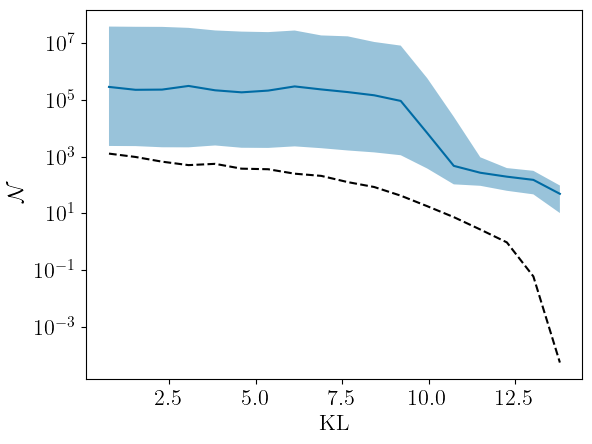

In [47]:
fig, ax = plt.subplots()


median = [ np.median(ints_kl[kl]) for kl  in kl_levels]
low = [ np.quantile(ints_kl[kl], 0.05) for kl  in kl_levels]
high = [ np.quantile(ints_kl[kl], 0.95) for kl  in kl_levels]


ax.plot(kl_levels, true_quantities_kl, "--", color="black", zorder=3, label="True (from `astro' pop)")
ax.plot(kl_levels, median, label='Inferred')
ax.fill_between(kl_levels, low, high, alpha=0.4)

plt.xlabel('KL')
plt.ylabel('$\\mathcal{N}$')

# np.savez("2D_volume_KL.np", kl=kl_levels, median=median, low=low, high=high)

plt.yscale('log')
plt.show()
plt.close()

In [48]:

# delta_levels = np.linspace(-9, -1.2, 20)
delta_levels = np.linspace(-np.amax(diff), -np.amin(diff), 20)[:-1]
xmin_delta={}
xmax_delta={}
ymin_delta={}
ymax_delta={}
zmin_delta={}
zmax_delta={}
for delta in delta_levels:
    ndraw=10000000
    proposals=np.zeros((ndraw,3))

    proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
    proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
    proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)


    inds_proposal_keep=np.argwhere(interp_delta(proposals)>delta-0.02)[:,0]

    xmin_delta[delta]=np.amin(proposals[inds_proposal_keep,0])
    xmax_delta[delta]=np.amax(proposals[inds_proposal_keep,0])
    ymin_delta[delta]=np.amin(proposals[inds_proposal_keep,1])
    ymax_delta[delta]=np.amax(proposals[inds_proposal_keep,1])
    zmin_delta[delta]=np.amin(proposals[inds_proposal_keep,2])
    zmax_delta[delta]=np.amax(proposals[inds_proposal_keep,2])


    

In [49]:
samples_per_tri = 1_000
num_triangulations = len(selected_tris)

# print(delta)
ndraw=10000


# volume = np.prod(get_corners(3).max(axis=0) - get_corners(3).min(axis=0))
volume = np.prod(corners_3d.max(axis=0) - corners_3d.min(axis=0))

ints_delta={}
for delta in np.flip(delta_levels):

    nprop=0
    nkeep=0
    nkeep_old=0

    print(delta)

    proposals=np.zeros((ndraw,3))

    while nkeep<ndraw:
        

        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(min_z,max_z,ndraw-nkeep)


        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_delta(new_points)>delta)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)

        nkeep+=len(inds_proposal_keep)

        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

        nkeep_old+=len(inds_proposal_keep)

    print(len(proposals))


    frac_kept = nkeep / nprop

    selected_tris=np.random.choice(len(all_triangulations), size=num_triangulations, replace=False)

    ints_delta[delta]=np.zeros(num_triangulations)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(all_triangulations[tri_ind])
        # samples_ind=this_delo.condition_sample_3d(samples_per_tri, xmin_delta[delta], xmax_delta[delta], ymin_delta[delta], ymax_delta[delta], zmin_delta[delta], zmax_delta[delta], interp_delta, delta, weight_fun=None)
        # # print(len(samples_ind))
        # if len(samples_ind)<samples_per_tri:
        #     inds_to_use=np.random.choice(np.arange(len(samples_ind)),samples_per_tri,replace=True)
        #     samples_ind=samples_ind[inds_to_use]
        
        mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        
        
        # print(mean_fx,frac_kept,volume)
        ints_delta[delta][ind]= mean_fx * frac_kept * volume
        # ints_kl[kl][ind]= mean_fx * volume
    # print(np.exp(-6)* frac_kept * volume,np.amax(np.exp(this_delo.interpolate(samples_ind))),np.amax(np.exp(this_delo.interpolate(samples_ind)))*frac_kept * volume)

-16.633560242385897
10000


 21%|█████████████████████████▉                                                                                               | 429/2000 [00:01<00:03, 424.70it/s]/tmp/ipykernel_59647/2085825018.py:60: RuntimeWarning: overflow encountered in exp
  mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:04<00:00, 401.67it/s]


-30.646064193661914
10000


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:05<00:00, 342.72it/s]


-44.65856814493793
10000


...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:08<00:00, 234.45it/s]


-254.84612741407818
10000


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:06<00:00, 321.19it/s]


-268.8586313653542
10000


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:06<00:00, 313.97it/s]


In [50]:
true_quantities = np.zeros(len(delta_levels))

ndim = 3
true_N = 1000
# gt_distro = stats.multivariate_normal(mean, cov)
gt_distro = MixtureModel(
        dist1 = stats.multivariate_normal(mean1, cov1),
        dist2 = stats.multivariate_normal(mean2, cov2),
        weight1 = 0.7,
    )

# volume = np.prod(get_corners(3).max(axis=0) - get_corners(3).min(axis=0))
volume = np.prod(corners_3d.max(axis=0) - corners_3d.min(axis=0))

for delta_ind, delta_level in enumerate(delta_levels):

    # proposals=np.zeros((ndraw*100,3))

    # proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
    # proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
    # proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)


    # inds_proposal_keep=np.argwhere( interp_delta(proposals) > delta_level)[:,0]  

    # print(len(inds_proposal_keep))  

    nprop=0
    nkeep=0
    nkeep_old=0

    print(delta_level)

    proposals=np.zeros((ndraw,3))

    while nkeep<ndraw:
        

        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(min_z,max_z,ndraw-nkeep)


        nprop+=ndraw-nkeep
        
        inds_proposal_keep=np.argwhere(interp_delta(new_points)>delta_level)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)

        nkeep+=len(inds_proposal_keep)

        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

        nkeep_old+=len(inds_proposal_keep)
    
    frac_kept = nkeep / nprop
    # re_samples = this_delo.re_sample(proposals[inds_proposal_keep], nmax=samples_per_tri)
    
    mean_fx = gt_distro.pdf(proposals).mean()
    # frac_kept = len(inds_proposal_keep) / len(proposals)
    
    true_quantities[delta_ind] = true_N * mean_fx * frac_kept * volume

-268.8586313653542
-254.84612741407818
-240.83362346280217
-226.82111951152615
-212.80861556025013
-198.79611160897412
-184.7836076576981
-170.77110370642208
-156.75859975514607
-142.74609580387005
-128.73359185259403
-114.72108790131801
-100.708583950042
-86.69607999876598
-72.68357604748996
-58.67107209621395
-44.65856814493793
-30.646064193661914
-16.633560242385897


<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_59647/3374731274.py:14: SyntaxWarning: invalid escape sequence '\D'
  ax.set_xlabel('$\Delta$')


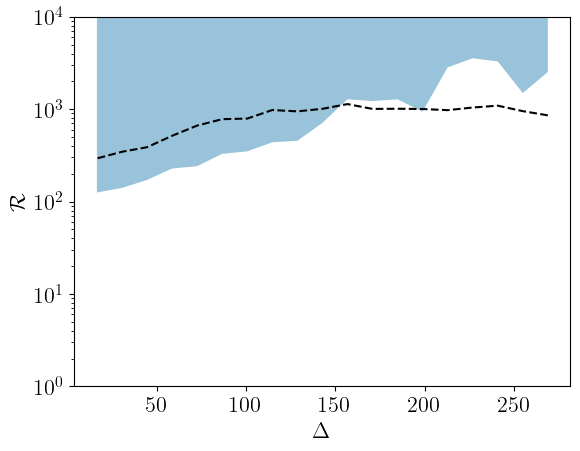

In [52]:
fig, ax = plt.subplots()


median = [ np.median(ints_delta[delta]) for delta  in delta_levels]
low = [ np.quantile(ints_delta[delta], 0.05) for delta  in delta_levels]
high = [ np.quantile(ints_delta[delta], 0.95) for delta  in delta_levels]


ax.plot(-delta_levels, true_quantities, "--", color="black", zorder=3, label="True (from `astro' pop)")
ax.plot(-delta_levels, median, label='Inferred')
ax.fill_between(-delta_levels, low, high, alpha=0.4)

# np.savez("3D_volume_delta.np", kl=kl_levels, median=median, low=low, high=high)
ax.set_xlabel('$\Delta$')
ax.set_ylabel('$\\mathcal{N}$')
ax.set_yscale('log')
ax.set_ylim(1e0,1e4)
# plt.savefig("3D_volume_delta")
plt.show()
plt.close()

(array([  19.,   60.,  154.,  313.,  458.,  565.,  659.,  794.,  974.,
        1004.]),
 array([-28.14441685, -25.09562994, -22.04684303, -18.99805612,
        -15.94926921, -12.9004823 ,  -9.8516954 ,  -6.80290849,
         -3.75412158,  -0.70533467,   2.34345224]),
 <BarContainer object of 10 artists>)

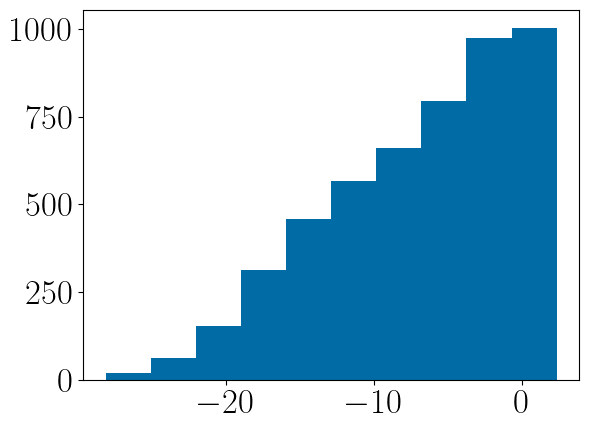

In [43]:
# plt.hist(np.log(true_N*gt_distro.pdf(samples_try)))

In [53]:
dm_levels=np.linspace(0.5,10,30)

samples_per_tri = 1_000
num_triangulations = 500

# print(delta)
# ndraw=10000000
# proposals=np.zeros((ndraw,3))

# proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
# proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
# proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)

# volume = np.prod(get_corners(3).max(axis=0) - get_corners(3).min(axis=0))

Sigma_inv = np.linalg.inv(cov)


ints_dm={}

# samples_gauss = gt_distro.rvs(ndraw)
# pdfs_gauss=gt_distro.pdf(samples_gauss)

ndraw=5000


proposals=np.zeros((ndraw,3))

proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)

volume = np.prod(get_corners(3).max(axis=0) - get_corners(3).min(axis=0))


for dm in dm_levels:


    nprop=0
    nkeep=0
    nkeep_old=0

    print(dm)

    proposals=np.zeros((ndraw,3))

    while nkeep<ndraw:
        
        # print(nkeep)

        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(min_z,max_z,ndraw-nkeep)


        nprop+=ndraw-nkeep


        diff = new_points - mean
        d2 = np.einsum("ni,ij,nj->n", diff, Sigma_inv, diff)  # shape (N,)
        
        inds_proposal_keep=np.argwhere(d2 <= dm**2)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)

        nkeep+=len(inds_proposal_keep)

        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

        nkeep_old+=len(inds_proposal_keep)


    frac_kept=nkeep/nprop
    
    # # Compute squared Mahalanobis distances
    # diff = proposals - mean
    # d2 = np.einsum("ni,ij,nj->n", diff, Sigma_inv, diff)  # shape (N,)

    # # Fixed threshold
   
    # mask = d2 <= dm**2    # keep points inside ellipsoid
    # samples_ind = proposals[mask]

    # # print(dm)
    
    # # inds_proposal_keep=np.argwhere(interp_delta(proposals)>delta)[:,0]
    # frac_kept = np.sum(mask)/ len(proposals)

    # # print(np.sum(mask))


    selected_tris=np.random.choice(len(triangulations), size=num_triangulations, replace=False)

    ints_dm[dm]=np.zeros(num_triangulations)

    for ind, tri_ind in enumerate(tqdm(selected_tris)):
        this_delo = delaunaytor.CPUDelaunayInterpolator()
        this_delo.triangulate(triangulations[tri_ind])
        # samples_ind=this_delo.condition_sample_3d(samples_per_tri, xmin_delta[delta], xmax_delta[delta], ymin_delta[delta], ymax_delta[delta], zmin_delta[delta], zmax_delta[delta], interp_delta, delta, weight_fun=None)
        # # print(len(samples_ind))
        # if len(samples_ind)<samples_per_tri:
        #     inds_to_use=np.random.choice(np.arange(len(samples_ind)),samples_per_tri,replace=True)
        #     samples_ind=samples_ind[inds_to_use]
        
        mean_fx = (np.exp(this_delo.interpolate(proposals))).mean()
        
        
        # print(mean_fx,frac_kept,volume)
        ints_dm[dm][ind]= mean_fx * frac_kept * volume
        # ints_kl[kl][ind]= mean_fx * volume
    # print(np.exp(-6)* frac_kept * volume,np.amax(np.exp(this_delo.interpolate(samples_ind))),np.amax(np.exp(this_delo.interpolate(samples_ind)))*frac_kept * volume)


0.5


100%|██████████| 500/500 [00:00<00:00, 880.07it/s]


0.8275862068965517


100%|██████████| 500/500 [00:00<00:00, 891.22it/s]


1.1551724137931034


...

100%|██████████| 500/500 [00:01<00:00, 362.40it/s]


9.672413793103448


100%|██████████| 500/500 [00:01<00:00, 442.97it/s]


10.0


100%|██████████| 500/500 [00:01<00:00, 451.50it/s]


In [56]:
true_quantities_dm = np.zeros(len(dm_levels))

ndim = 3
true_N = 1000
gt_distro = stats.multivariate_normal(mean, cov)


ndraw=50000


proposals=np.zeros((ndraw,3))

proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)

volume = np.prod(get_corners(3).max(axis=0) - get_corners(3).min(axis=0))

for dm_ind, dm_level in enumerate(dm_levels):

    # # proposals=np.zeros((ndraw*100,3))

    # # proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
    # # proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
    # # proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)

    # diff = proposals - mean
    # d2 = np.einsum("ni,ij,nj->n", diff, Sigma_inv, diff)  # shape (N,)

    # # Fixed threshold
   
    # mask = d2 <= dm_level**2    # keep points inside ellipsoid
    # samples_ind = proposals[mask]

    # # print(dm)
    
    # # inds_proposal_keep=np.argwhere(interp_delta(proposals)>delta)[:,0]
    # frac_kept = np.sum(mask)/ len(proposals)

    nprop=0
    nkeep=0
    nkeep_old=0

    print(dm)

    proposals=np.zeros((ndraw,3))

    while nkeep<ndraw:
        
        # print(nkeep)

        new_points=np.zeros((ndraw-nkeep,3))
        new_points[:,0]=np.random.uniform(min_x,max_x,ndraw-nkeep)
        new_points[:,1]=np.random.uniform(min_y,max_y,ndraw-nkeep)
        new_points[:,2]=np.random.uniform(min_z,max_z,ndraw-nkeep)


        nprop+=ndraw-nkeep


        diff = new_points - mean
        d2 = np.einsum("ni,ij,nj->n", diff, Sigma_inv, diff)  # shape (N,)
        
        inds_proposal_keep=np.argwhere(d2 <= dm_level**2)[:,0]
        # frac_kept = len(inds_proposal_keep) / len(proposals)

        nkeep+=len(inds_proposal_keep)

        proposals[nkeep_old:nkeep]=new_points[inds_proposal_keep]

        nkeep_old+=len(inds_proposal_keep)


    frac_kept=nkeep/nprop

    

    print(np.sum(mask))
        
    # re_samples = this_delo.re_sample(proposals[inds_proposal_keep], nmax=samples_per_tri)
    
    mean_fx = gt_distro.pdf(proposals).mean()
    # frac_kept = np.sum(mask) / len(proposals)
    true_quantities_dm[dm_ind] = true_N * mean_fx * frac_kept * volume

10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000
10.0
5000


[  30.94249725  123.16791121  280.13311091  467.86162683  643.27225176
  796.35199563  904.16646217  945.85789024  969.5146746   990.51738726
 1005.59839998 1000.58745188  987.39700594  996.92685072  993.26002788
  968.27423126  989.8102271   976.25954409  992.30869417  990.28378205
 1000.75854633  979.85380755 1005.56151424  980.76990635  983.63280722
  989.48705969  994.77786227 1010.80338576 1002.50901554  988.94632927]


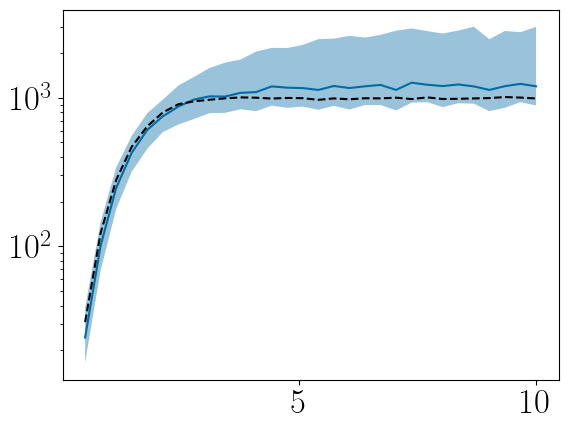

In [57]:
fig, ax = plt.subplots()


median = [ np.median(ints_dm[dm]) for dm  in dm_levels]
low = [ np.quantile(ints_dm[dm], 0.05) for dm  in dm_levels]
high = [ np.quantile(ints_dm[dm], 0.95) for dm  in dm_levels]


ax.plot(dm_levels, true_quantities_dm, "--", color="black", zorder=3, markerfacecolor="white")
ax.errorbar(dm_levels, median)
ax.fill_between(dm_levels, low, high, alpha=0.4)

# np.savez("3D_volume_delta.np", kl=kl_levels, median=median, low=low, high=high)
plt.yscale('log')
plt.savefig("3D_volume_delta")


print(true_quantities_dm)

In [239]:
ind_marg=1
ind_keep1=0
ind_keep2=2

grids={2:z_grid,1:y_grid,0:x_grid}
grids_coarse={2:z_grid_coarse,1:y_grid_coarse,0:x_grid_coarse}

mins={2:min_z,1:min_y,0:min_x}
maxs={2:max_z,1:max_y,0:max_x}

In [240]:
square_rate_2d=np.log10(np.trapezoid(np.exp(square_rate),axis=ind_marg+1,x=grids[ind_marg]))
square_rate_2d_coarse=np.log10(np.trapezoid(np.exp(square_rate_coarse),axis=ind_marg+1,x=grids_coarse[ind_marg]))

In [241]:
median_2d = np.quantile(square_rate_2d, 0.5, axis=0)
low_2d = np.quantile(square_rate_2d, 0.05, axis=0)
high_2d = np.quantile(square_rate_2d, 0.95, axis=0)

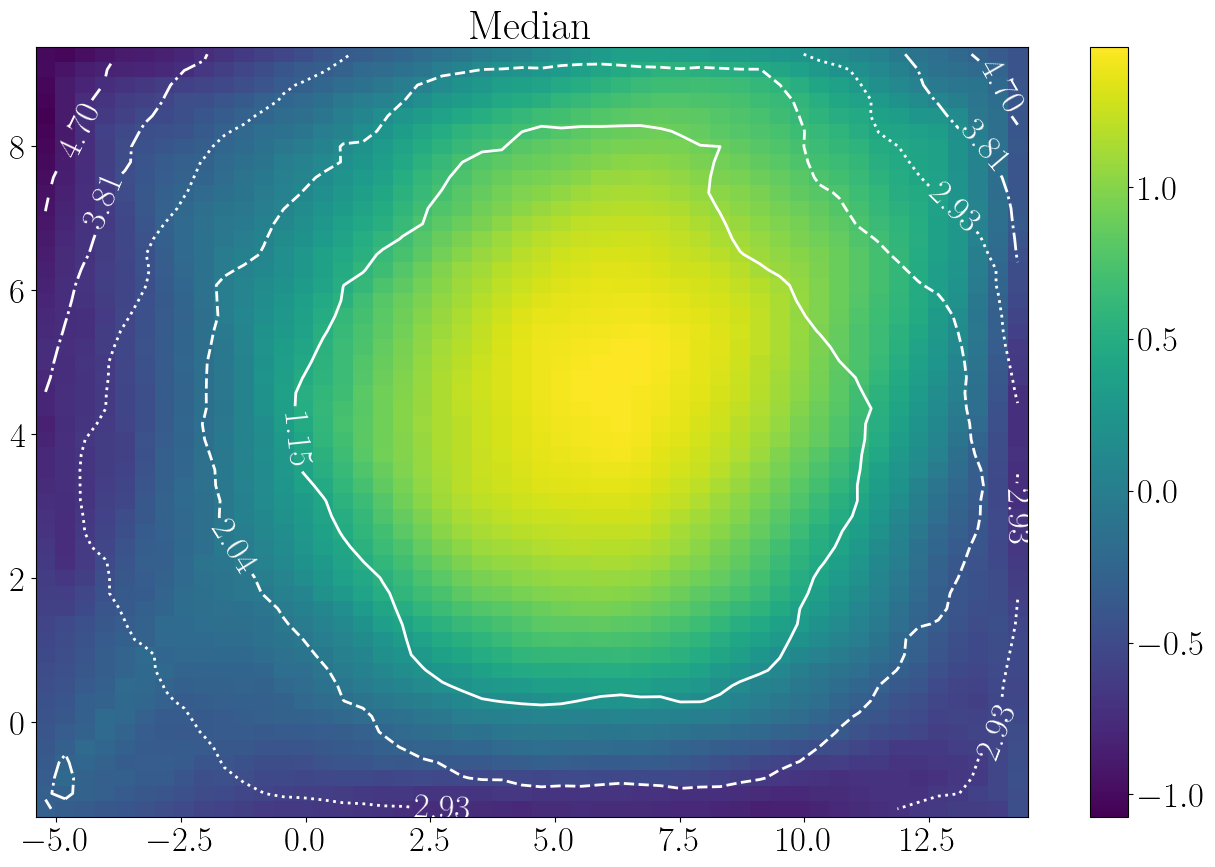

In [242]:

fig, ax = plt.subplots(figsize=(16, 10))
ax.set(title=f"Median ")
c = ax.pcolormesh(grids[ind_keep1], grids[ind_keep2], median_2d)    
fig.colorbar(c)


# Calculate the difference
diff = high_2d - low_2d

# Define contour levels (choose appropriate values for your data)
n_contours = min(5, len(linestyles))
levels = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

# Plot contours with different linestyles
contours = ax.contour(
    grids[ind_keep1], grids[ind_keep2], diff, 
    levels=levels, 
    linestyles=linestyles[:n_contours],
    linewidths=2, 
    colors='white'
)


# mu_cond, Sigma_cond = conditional_gaussian(mean, cov, z_grid[z_idx])

# colors = ['r','g','b']

# for n, c in zip([1,2,3], colors):
#     plot_ellipse(mu_cond, Sigma_cond, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=f"{n}σ")


# Optional: add labels to contours
ax.clabel(contours, fmt="%.2f")

plt.show()
plt.close()

In [243]:
square_rate_2d_prior_coarse = np.log10(np.trapezoid(np.exp(square_rate_prior_coarse),axis=ind_marg+1,x=grids_coarse[ind_marg]))

# print(square_rate_prior.shape)

In [244]:
kl_divs_2d=np.zeros((len(x_grid_coarse),len(y_grid_coarse)))

for i in tqdm(range(len(grids_coarse[ind_keep1]))):
    for j in range(len(grids_coarse[ind_keep2])):
        
        # print(i,j)

            # if (i==0 and j==0 and k==0) or (i==0 and j==99 and k==0) or (i==99 and j==0 and k==0) or (i==99 and j==99 and k==0) or (i==0 and j==0 and k==99) or (i==0 and j==99 and k==99) or (i==99 and j==0 and k==99) or (i==99 and j==99 and k==1):
            # if (i==0 and j==0 and k==0) or (i==0 and j==19 and k==0) or (i==19 and j==0 and k==0) or (i==19 and j==19 and k==0) or (i==0 and j==0 and k==19) or (i==0 and j==19 and k==99) or (i==19 and j==0 and k==19) or (i==19 and j==19 and k==1):

            #     kl_divs_2d[i,j]=kl_divergence_kde_p_known_q(square_rate_coarse[:,i,j,k],q_flat)

            # else:

        kl_divs_2d[i,j]=kl_divergence_kde(square_rate_2d_coarse[:,i,j],square_rate_2d_prior_coarse[:,i,j])

100%|██████████| 20/20 [00:02<00:00,  7.64it/s]


In [245]:
interp_2d_kl = RegularGridInterpolator((grids_coarse[ind_keep1], grids_coarse[ind_keep2]), kl_divs_2d, bounds_error=False, fill_value=np.nan)

X2d,Y2d=np.meshgrid(grids[ind_keep1],grids[ind_keep2])

grid_2d = np.c_[X2d.ravel(), Y2d.ravel()]


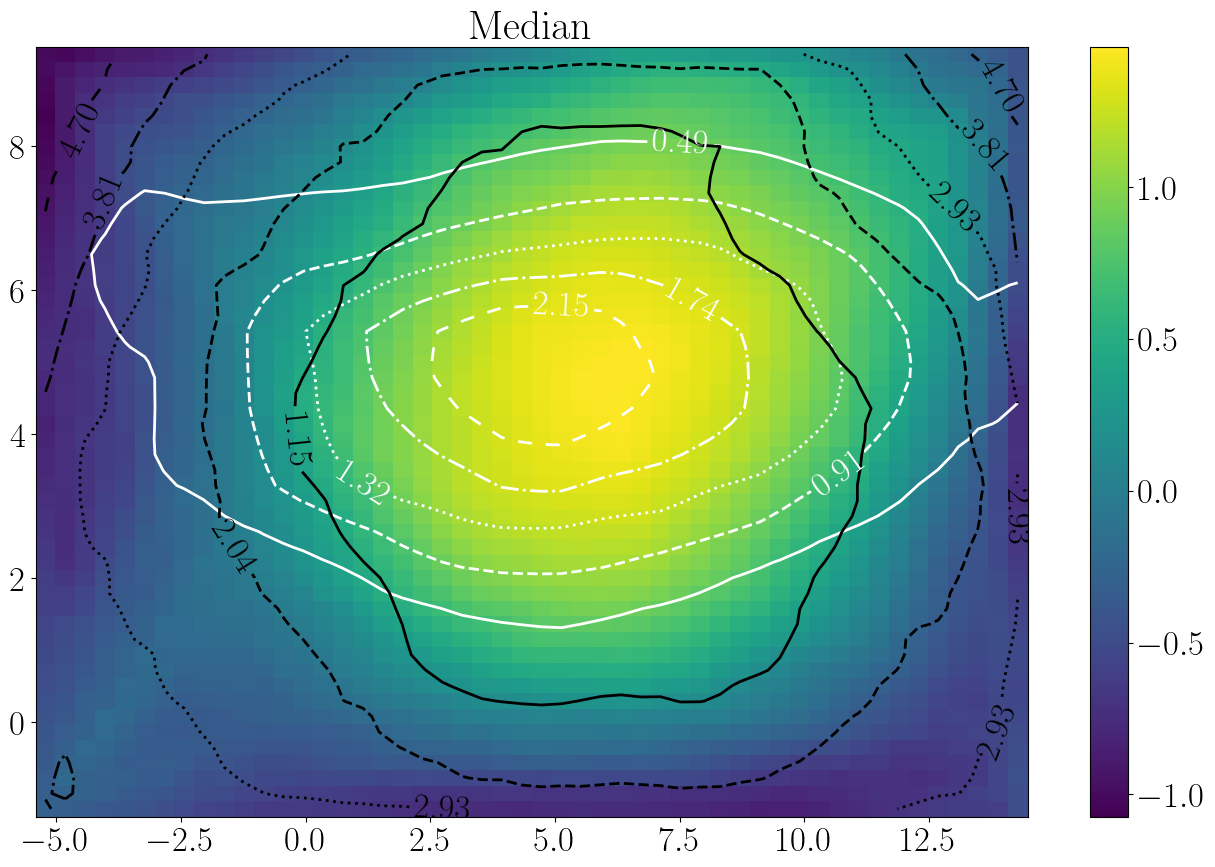

In [246]:

fig, ax = plt.subplots(figsize=(16, 10))
ax.set(title=f"Median ")
c = ax.pcolormesh(grids[ind_keep1],grids[ind_keep2], median_2d)    
fig.colorbar(c)


# Calculate the difference
diff = high_2d - low_2d

# Define contour levels (choose appropriate values for your data)
n_contours = min(5, len(linestyles))
levels_diff = np.linspace(np.nanmin(diff), np.nanmax(diff), n_contours + 2)[1:-1]  # avoid min/max

levels_kl = np.linspace(np.nanmin(kl_divs_2d), np.nanmax(kl_divs_2d), n_contours + 2)[1:-1]  # avoid min/max

contours_kl = ax.contour(
    grids[ind_keep1], grids[ind_keep2], interp_2d_kl(grid_2d).reshape((len(x_grid),len(y_grid))), 
    levels=levels_kl, 
    linestyles=linestyles[:n_contours],
    linewidths=2, 
    colors='white'
)

# Plot contours with different linestyles
contours_diff = ax.contour(
    grids[ind_keep1], grids[ind_keep2], diff, 
    levels=levels_diff, 
    linestyles=linestyles[:n_contours],
    linewidths=2, 
    colors='black'
)


# mu_cond, Sigma_cond = conditional_gaussian(mean, cov, z_grid[z_idx])

# colors = ['r','g','b']

# for n, c in zip([1,2,3], colors):
#     plot_ellipse(mu_cond, Sigma_cond, ax, n_std=n, edgecolor=c, fill=False, lw=2, label=f"{n}σ")


# Optional: add labels to contours
ax.clabel(contours_diff, fmt="%.2f")

ax.clabel(contours_kl, fmt="%.2f")

plt.show()
plt.close()

In [247]:
# kl_levels=[0,0.5,1,1.5,2.]
# xmin_2d_kl={}
# xmax_2d_kl={}
# ymin_2d_kl={}
# ymax_2d_kl={}

# for kl in kl_levels:
#     ndraw=10000000
#     proposals=np.zeros((ndraw,2))

#     proposals[:,0]=np.random.uniform(mins[ind_keep1],maxs[ind_keep1],ndraw)
#     proposals[:,1]=np.random.uniform(mins[ind_keep2],maxs[ind_keep2],ndraw)
    


#     inds_proposal_keep=np.argwhere(interp_2d_kl(proposals)>kl-0.02)[:,0]

#     xmin_2d_kl[kl]=np.amin(proposals[inds_proposal_keep,0])
#     xmax_2d_kl[kl]=np.amax(proposals[inds_proposal_keep,0])
#     ymin_2d_kl[kl]=np.amin(proposals[inds_proposal_keep,1])
#     ymax_2d_kl[kl]=np.amax(proposals[inds_proposal_keep,1])



    

In [248]:

# xmin_kl={}
# xmax_kl={}
# ymin_kl={}
# ymax_kl={}
# zmin_kl={}
# zmax_kl={}
# for kl in kl_levels:
#     ndraw=10000000
#     proposals=np.zeros((ndraw,3))

#     proposals[:,0]=np.random.uniform(min_x,max_x,ndraw)
#     proposals[:,1]=np.random.uniform(min_y,max_y,ndraw)
#     proposals[:,2]=np.random.uniform(min_z,max_z,ndraw)


#     inds_proposal_keep=np.argwhere(interp_kl(proposals)>kl-0.02)[:,0]

#     xmin_kl[kl]=np.amin(proposals[inds_proposal_keep,0])
#     xmax_kl[kl]=np.amax(proposals[inds_proposal_keep,0])
#     ymin_kl[kl]=np.amin(proposals[inds_proposal_keep,1])
#     ymax_kl[kl]=np.amax(proposals[inds_proposal_keep,1])
#     zmin_kl[kl]=np.amin(proposals[inds_proposal_keep,2])
#     zmax_kl[kl]=np.amax(proposals[inds_proposal_keep,2])


    

In [249]:
# from scipy.stats import spearmanr
# from ennemi import estimate_corr

# # samples_kl={}
# spearmans_2d_kl={}
# mic_2d_kl={}
# for kl in kl_levels:

#     print(kl)
#     # ndraw=10000000
#     # proposals=np.zeros((ndraw,2))

#     # proposals[:,0]=np.random.uniform(xmin_kl[kl],xmax_kl[kl],ndraw)
#     # proposals[:,1]=np.random.uniform(ymin_kl[kl],ymax_kl[kl],ndraw)


#     # inds_proposal_keep=np.argwhere(interp(proposals)>kl)[:,0]

#     # proposals[inds_proposal_keep]


#     samples_per_tri = 1000
#     num_triangulations=1000
#     selected_tris=np.random.choice(len(triangulations), size=num_triangulations, replace=False)


#     # samples_kl[kl] = np.zeros((num_triangulations, samples_per_tri, 2))

#     spearmans_2d_kl[kl]=np.zeros(num_triangulations)
#     mic_2d_kl[kl]=np.zeros(num_triangulations)

#     for ind, tri_ind in enumerate(tqdm(selected_tris)):
#         this_delo = delaunaytor.CPUDelaunayInterpolator()
#         this_delo.triangulate(triangulations[tri_ind])
#         # samples_ind=this_delo.re_sample(proposals[inds_proposal_keep],nmax=samples_per_tri)
#         # print(len(samples_ind))
#         samples_ind=this_delo.condition_sample_3d(samples_per_tri, xmin_kl[kl], xmax_kl[kl], ymin_kl[kl], ymax_kl[kl], zmin_kl[kl], zmax_kl[kl], interp_kl, kl, weight_fun=None)
#         if len(samples_ind)<samples_per_tri:
#             print('have to add:',len(samples_ind))
#             inds_to_use=np.random.choice(np.arange(len(samples_ind)),samples_per_tri,replace=True)
#             samples_ind=samples_ind[inds_to_use]
#         # samples_kl[kl][ind] = samples_ind
#         # print(spearmanr(samples_ind),spearmans_kl[kl][ind])
#         spearmans_2d_kl[kl][ind]=spearmanr(samples_ind[:,[ind_keep1,ind_keep2]]).statistic

#         # kde2d=gaussian_kde(samples_ind.T, bw_method='scott')
#         # kdex=gaussian_kde(samples_ind[:,0], bw_method='scott')
#         # kdey=gaussian_kde(samples_ind[:,1], bw_method='scott')

#         # mi_ind=max(0,np.mean(np.log(kde2d(samples_ind.T)/(kdex(samples_ind[:,0])*kdey(samples_ind[:,1])))))

#         # mic_kl[kl][ind]=np.sqrt(1.-np.exp(-2*mi_ind))

#         mic_2d_kl[kl][ind]=estimate_corr(samples_ind[:,ind_keep2],samples_ind[:,ind_keep1])

#         # if np.isnan(mic_kl[kl][ind]):
#         #     print('nan:',mi_ind)


#     #     if ind<10:
            
#     #         plt.figure()
#     #         plt.scatter(samples_ind[:,0],samples_ind[:,1])

#     #         # print(len(samples_ind))

#     # plt.show()
            

0


  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_4156/2738298152.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mic_2d_kl[kl][ind]=estimate_corr(samples_ind[:,ind_keep2],samples_ind[:,ind_keep1])
100%|██████████| 1000/1000 [00:20<00:00, 49.43it/s]


0.5


100%|██████████| 1000/1000 [00:25<00:00, 39.68it/s]


1


100%|██████████| 1000/1000 [00:19<00:00, 52.03it/s]


1.5


100%|██████████| 1000/1000 [00:16<00:00, 59.04it/s]


2.0


100%|██████████| 1000/1000 [00:15<00:00, 65.66it/s]


In [ ]:

# nsamples_prior=2000
# log_rate_prior = np.zeros((nsamples_prior, grid.shape[0]))

# kl_divs_prior=np.zeros((len(x_grid),len(y_grid)))

# samples_per_tri=1000

# spearmans_prior=np.zeros(nsamples_prior)

# mic_prior=np.zeros(nsamples_prior)


# for i in tqdm(range(nsamples_prior)):

#     nleaves_i=np.random.randint(4,101)

#     tri_i=np.zeros((nleaves_i+8,4))

#     tri_i[:nleaves_i,0]=np.random.uniform(min_x,max_x,nleaves_i)
#     tri_i[:nleaves_i,1]=np.random.uniform(min_y,max_y,nleaves_i)
#     tri_i[:nleaves_i,2]=np.random.uniform(min_z,max_z,nleaves_i)
#     tri_i[:,3]=np.random.uniform(-15,5,nleaves_i+8)

#     tri_i[-8,0]=min_x
#     tri_i[-8,1]=min_y
#     tri_i[-8,2]=min_z

#     tri_i[-7,0]=min_x
#     tri_i[-7,1]=min_y
#     tri_i[-7,2]=max_z


#     tri_i[-6,0]=min_x
#     tri_i[-6,1]=max_y
#     tri_i[-6,2]=min_z


#     tri_i[-5,0]=min_x
#     tri_i[-5,1]=max_y
#     tri_i[-5,2]=max_z


#     tri_i[-4,0]=max_x
#     tri_i[-4,1]=min_y
#     tri_i[-4,2]=min_z

#     tri_i[-3,0]=max_x
#     tri_i[-3,1]=min_y
#     tri_i[-3,2]=max_z

#     tri_i[-2,0]=max_x
#     tri_i[-2,1]=max_y
#     tri_i[-2,2]=min_z

#     tri_i[-1,0]=max_x
#     tri_i[-1,1]=max_y
#     tri_i[-1,2]=max_z

   
#     this_delo = delaunaytor.CPUDelaunayInterpolator()
#     this_delo.triangulate(tri_i)
   
#     samples_ind=this_delo.sample(samples_per_tri)
       
#     spearmans_prior[i]=spearmanr(samples_ind[:,[ind_keep1,ind_keep2]]).statistic


#     # kdexy=gaussian_kde(samples_ind.T, bw_method='scott')
#     # kdex=gaussian_kde(samples_ind[:,0], bw_method='scott')
#     # kdey=gaussian_kde(samples_ind[:,1], bw_method='scott')

#     # mi_ind=np.mean(np.log(kdexy(samples_ind.T)/(kdex(samples_ind[:,0])*kdey(samples_ind[:,1]))))

#     mic_prior[i]=estimate_corr(samples_ind[:,ind_keep2],samples_ind[:,ind_keep1])



  0%|          | 0/2000 [00:00<?, ?it/s]/tmp/ipykernel_4156/1644801657.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mic_prior[i]=estimate_corr(samples_ind[:,ind_keep2],samples_ind[:,ind_keep1])
100%|██████████| 2000/2000 [02:04<00:00, 16.07it/s]


<>:28: SyntaxWarning: invalid escape sequence '\ '
<>:28: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_4156/3904981728.py:28: SyntaxWarning: invalid escape sequence '\ '
  sns.histplot( spearmans_2d_kl[kl],label='${\\rm KL  \ limit \ is:%1.1f}$'%kl,ax=ax,stat='density')


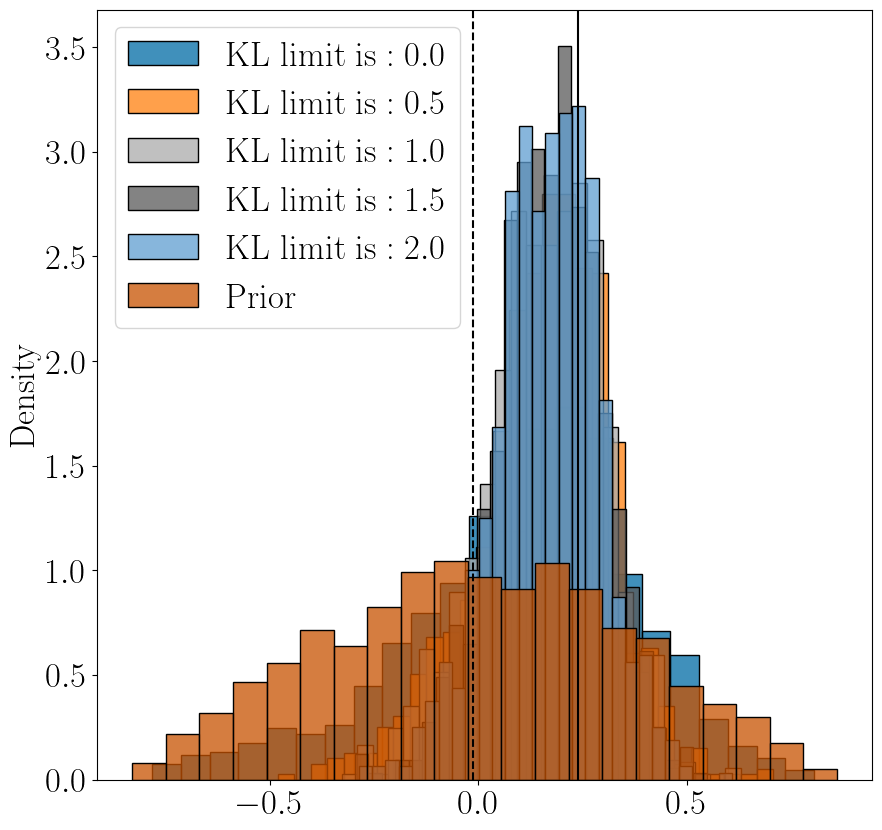

In [254]:
# import seaborn as sns

# fig,ax=plt.subplots(figsize=(10,10))

# # print(int(file_3d['detected_injections']),int(file_3d['samples_per_event']))

# # print(file_3d['observed_events'].reshape((-1,file_3d['samples_per_event'],3)))

# spearmanr_2d_true_obs=spearmanr(np.mean(file_3d['observed_events'].reshape(-1,file_3d['samples_per_event'],3),axis=0)[:,[ind_keep1,ind_keep2]])[0]


# samples_true_pop=gt_distro.rvs(100000)

# spearmanr_2d_true=spearmanr(samples_true_pop[:,[ind_keep1,ind_keep2]])[0]


# # print('spearman obs:',spearmanr_2d_true_obs)

# # file_3d=np.load('data_test_3dim_3D_1000_events_10000_samples_1000000_injections/data.npz')
# # observed_events=file_3d['observed_events']
# # mins, maxs = observed_events.min(axis=0), observed_events.max(axis=0)
# # pad = (maxs - mins) * 0.1
# # bounds = list(zip(mins - pad, maxs + pad))
# # corners_3d = np.array(list(product(*bounds)))

# for kl in kl_levels:

#     sns.histplot( spearmans_2d_kl[kl],label='${\\rm KL  \ limit \ is:%1.1f}$'%kl,ax=ax,stat='density')

# sns.histplot( spearmans_prior,label='${\\rm Prior}$',ax=ax,stat='density')

# plt.axvline(x=spearmanr_2d_true,c='k')
# plt.axvline(x=spearmanr_2d_true_obs,c='k',ls='--')

# ax.legend()


<>:22: SyntaxWarning: invalid escape sequence '\ '
<>:22: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_4156/136269264.py:22: SyntaxWarning: invalid escape sequence '\ '
  sns.histplot( mic_2d_kl[kl],label='${\\rm KL  \ limit \ is:%1.1f}$'%kl,ax=ax,stat='density')


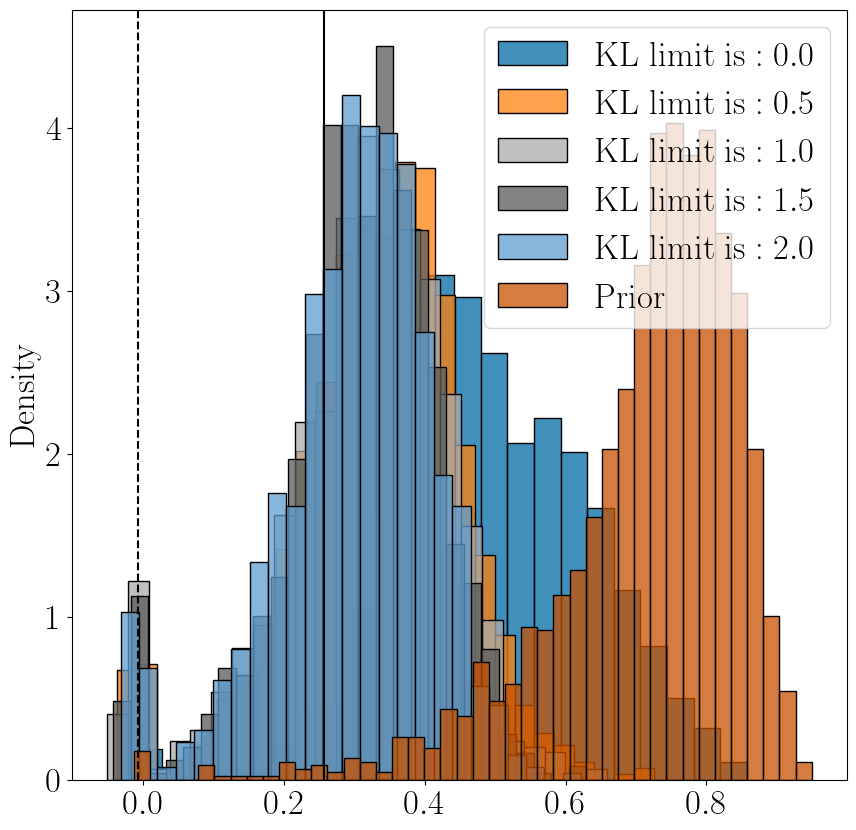

In [255]:
# fig,ax=plt.subplots(figsize=(10,10))

# # print(int(file_3d['detected_injections']),int(file_3d['samples_per_event']))

# # print(file_3d['observed_events'].reshape((-1,file_3d['samples_per_event'],3)))


# samples_true_pop=gt_distro.rvs(100000)

# mic_2d_true=estimate_corr(samples_true_pop[:,ind_keep2],samples_true_pop[:,ind_keep1])



# mic_2d_true_obs=estimate_corr(np.mean(file_3d['observed_events'].reshape(-1,file_3d['samples_per_event'],3),axis=0)[:,ind_keep2],np.mean(file_3d['observed_events'].reshape(-1,file_3d['samples_per_event'],3),axis=0)[:,ind_keep1])





# for kl in kl_levels:

#     sns.histplot( mic_2d_kl[kl],label='${\\rm KL  \ limit \ is:%1.1f}$'%kl,ax=ax,stat='density')

# sns.histplot( mic_prior,label='${\\rm Prior}$',ax=ax,stat='density')

# plt.axvline(x=mic_2d_true,c='k')
# plt.axvline(x=mic_2d_true_obs,c='k',ls='--')

# ax.legend()